# Lab Day 1 — Xây dựng mạng nơ-ron và thí nghiệm huấn luyện

**Track 4 · Ngày 1 · VinUniversity AICB 2026** · Bài toán: phân loại 7 loại rừng trên
Forest CoverType bằng MLP tự viết.

Notebook này chạy từ đầu đến cuối (`Restart & Run All`). Toàn bộ code nằm trong thư mục
`code/` (`data.py`, `model.py`, `optimizer.py`, `train.py`, `plots.py`, `results_table.py`),
mọi ô đều gọi hàm trong các module đó — không có logic huấn luyện nào nằm trực tiếp trong notebook.

**Cách chạy**

```bash
git clone <url-repo> && cd <repo>
python scripts/split_data.py           # tạo data/processed/{train,eval}.npz (~30 giây)
python -m pip install -r code/requirements.txt
```

Rồi mở `code/lab.ipynb` và **Restart & Run All** (hoặc File → Run All → Run All).
Kết quả ghi vào `<repo>/submission/` — ô Part 5 cuối notebook sẽ dựng đúng cấu trúc
`submission_<MSSV>/` theo README mục 6.1.

Chạy được trên máy có GPU, không cần mạng sau khi clone. Toàn bộ dữ liệu nằm sẵn trong repo
(`data/covtype.csv.gz` + `data/split_metadata.csv`), **không cần tải thêm**.

**Quy tắc bắt buộc của lab** (đã cài trong code, không vi phạm ở đâu)

- Tập `eval` **chỉ** dùng ở Part 4, cho baseline và cấu hình cuối cùng. Mọi lựa chọn dùng `val`.
- Mỗi thí nghiệm chỉ đổi **một** yếu tố so với baseline (trừ cấu hình cuối cùng, ghi rõ trong bảng).
- Cùng một phép tách val (20%, phân tầng, seed 42), cùng số epoch cho các thí nghiệm so sánh.
- Kết luận "A tốt hơn B" phải so với ngưỡng nhiễu 2σ đo từ các seed baseline.

**Chế độ kiểm tra nhanh:** đặt `FAST = True` trong ô setup (biến môi trường `LAB_FAST=1`) để
chạy thử với 2 epoch. Chạy thật thì để `FAST = False`.

In [1]:
# ===== 0. Môi trường, đường dẫn, cờ chạy =====
import os, sys, json, time, subprocess, shutil, math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import Image, display

CWD = os.getcwd()          # thư mục chứa lab.ipynb và các module .py

def is_repo_root(p):
    p = str(p)
    return (os.path.isfile(os.path.join(p, "data", "covtype.csv.gz"))
            and os.path.isfile(os.path.join(p, "scripts", "split_data.py")))

def is_code_dir(p):
    """Thư mục chứa các module .py của bạn (tức là nơi lab.ipynb nằm cùng chúng)."""
    p = str(p)
    return all(os.path.isfile(os.path.join(p, f)) for f in ("data.py", "model.py", "train.py"))

def find_repo_root():
    """Tự dò thư mục gốc repo (thư mục chứa data/covtype.csv.gz và scripts/split_data.py).

    Đi lên tối đa 8 cấp kể từ thư mục chứa notebook, rồi thử một thư mục con có tên repo
    nằm cạnh notebook. Nhờ vậy chạy được cả khi notebook đặt ở `<repo>/code/` lẫn ở
    `<submission>/code/`.
    """
    cands = []
    p = os.path.abspath(CWD)
    for _ in range(8):
        cands.append(p)
        parent = os.path.dirname(p)
        if parent == p:
            break
        p = parent
    cands.append(os.path.join(CWD, "K4-Track4-Day1-Neuralnetwork"))
    for c in cands:
        if is_repo_root(c):
            return os.path.abspath(c)
    return None

REPO_ROOT = find_repo_root()
assert REPO_ROOT, (
    "không tìm thấy thư mục gốc repo — tức là thư mục chứa `data/covtype.csv.gz` và "
    "`scripts/split_data.py`.\n"
    "Cách xử lý:\n"
    "  * chạy notebook từ `<repo>/code/` hoặc từ `<submission>/code/` — cả hai đều nằm trong repo\n"
    "    nên ô này tự dò ra; hoặc\n"
    "  * copy/clone repo về đây rồi mở notebook trong `<repo>/code/`:\n"
    "      git clone <url-repo> && cd <repo>/code")

# Thư mục chứa các module .py của bạn. Nếu lab.ipynb nằm cùng chỗ với .py thì dùng luôn CWD,
# còn nếu notebook đặt ở thư mục khác thì lấy từ <repo>/code/ (chạy được cả hai kiểu).
CODE_DIR = CWD if is_code_dir(CWD) else os.path.join(REPO_ROOT, "code")
assert is_code_dir(CODE_DIR), f"không thấy data.py/model.py/train.py trong {CODE_DIR}"
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

# --- Thư mục nộp (nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv):
#     * lab.ipynb nằm cùng .py trong <submission>/code/  -> OUT_DIR = <submission>
#     * chạy trong <repo>/code/                          -> tạo <repo>/submission_<tên>
# Có thể ép bằng biến môi trường LAB_OUT_DIR / LAB_SUBMISSION.
SUBMISSION_NAME = os.environ.get("LAB_SUBMISSION", "submission")

def pick_out_dir(cwd):
    if not is_code_dir(cwd):
        return cwd                                    # notebook không nằm cạnh .py -> dùng chính cwd
    parent = os.path.dirname(cwd)
    if not parent or not os.access(parent, os.W_OK):
        return cwd                                    # thư mục cha không ghi được -> dùng cwd
    if not is_repo_root(parent):
        return parent                                 # <submission>/code/ -> <submission>
    return os.path.join(REPO_ROOT, SUBMISSION_NAME)   # đang chạy trong code/ của repo

OUT_DIR = os.environ.get("LAB_OUT_DIR") or pick_out_dir(CWD)
FIGS_DIR, RES_DIR = f"{OUT_DIR}/figures", f"{OUT_DIR}/results"
for d in (FIGS_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

# --- encoding cho subprocess (scripts/*.py in tiếng Việt; console Windows mặc định cp1252)
SUBENV = {**os.environ, "PYTHONIOENCODING": "utf-8"}

# --- cờ chạy
FAST = os.environ.get("LAB_FAST", "0") == "1"          # True = kiểm tra nhanh (2 epoch)
EPOCHS       = 2 if FAST else 20                       # số epoch chuẩn của mọi thí nghiệm
EPOCHS_LONG  = 3 if FAST else 60                       # thí nghiệm "huấn luyện lâu hơn"
EPOCHS_FINAL = 2 if FAST else 40                       # cấu hình cuối cùng
SKIP_DONE = True     # bỏ qua thí nghiệm đã có results/<exp_id>.json (tiết kiệm thời gian khi chạy lại)

# --- thiết bị
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"notebook  = {CWD}   (có các file .py ở đây: {is_code_dir(CWD)})")
print(f"CODE_DIR  = {CODE_DIR}   (nơi import data / model / optimizer / train / plots / results_table)")
print(f"OUT_DIR   = {OUT_DIR}   (figures/ results/ experiments.xlsx predictions_eval.csv đều ở đây)")
print(f"torch     = {torch.__version__}")
print(f"device    = {device}", end="")
if device == "cuda":
    print(f"  |  GPU: {torch.cuda.get_device_name(0)}")
    print(f"             bf16 phần cứng được hỗ trợ: {torch.cuda.is_bf16_supported()}")
else:
    print()
print(f"FAST={FAST}  epochs={EPOCHS}  long={EPOCHS_LONG}  final={EPOCHS_FINAL}")

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

# ---- các module của bạn
from data import prepare_data, N_NUMERIC
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, build_scheduler, clip_gradients
from train import (DEFAULT_CFG, set_seed, evaluate, predict, compute_loss, run_experiment,
                   final_eval, write_predictions, macro_f1_from_confusion, LN_C)
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx, noise_stats
print("import OK:", sorted(f.split('/')[-1] for f in
      ["data.py", "model.py", "optimizer.py", "train.py", "plots.py", "results_table.py"]))

REPO_ROOT = C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork
notebook  = C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork\submission_2A202602590\code   (có các file .py ở đây: True)
CODE_DIR  = C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork\submission_2A202602590\code   (nơi import data / model / optimizer / train / plots / results_table)
OUT_DIR   = C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork\submission_2A202602590   (figures/ results/ experiments.xlsx predictions_eval.csv đều ở đây)
torch     = 2.12.0+cu126
device    = cuda  |  GPU: NVIDIA GeForce RTX 2050
             bf16 phần cứng được hỗ trợ: True
FAST=False  epochs=20  long=60  final=40


import OK: ['data.py', 'model.py', 'optimizer.py', 'plots.py', 'results_table.py', 'train.py']


---
## Part 0 — Dữ liệu

Chia sẵn bằng metadata: `scripts/split_data.py` đọc `data/covtype.csv.gz` + `data/split_metadata.csv`
rồi tạo `data/processed/{train,eval}.npz`. **Không** sửa metadata, **không** tự chia lại train/eval.

Sau đó: tách 20% validation từ `train` (phân tầng theo nhãn, seed 42), chuẩn hoá 10 cột số liên tục
bằng thống kê **chỉ của phần train còn lại**, rồi đưa toàn bộ lên GPU một lần (không dùng DataLoader).

In [2]:
# ---- Chạy scripts/split_data.py (bỏ qua nếu đã có .npz) ----
need_split = not all(os.path.isfile(f"{REPO_ROOT}/data/processed/{s}.npz") for s in ("train", "eval"))
if need_split:
    subprocess.run([sys.executable, os.path.join(REPO_ROOT, "scripts", "split_data.py")],
                   cwd=REPO_ROOT, check=True, env=SUBENV)
else:
    print("data/processed/*.npz đã tồn tại -> bỏ qua split_data.py")

# ---- Nạp + tách val + chuẩn hoá + đưa lên device ----
data = prepare_data(device, val_fraction=0.2, seed=42,
                    processed_dir=os.path.join(REPO_ROOT, "data", "processed"))

data/processed/*.npz đã tồn tại -> bỏ qua split_data.py


thiết bị: cuda
X_tr  (371847, 54)  |  X_val (92962, 54)  |  X_eval (116203, 54)
số mẫu: train 371847 / val 92962 / eval 116203  (kỳ vọng 371847 / 92962 / 116203)
lớp đa số trên val = 1 (48.76% mẫu); chiến lược 'luôn đoán lớp đa số' cho val acc = 0.4876  <- mốc phải vượt
X_tr 10 cột đầu sau chuẩn hoá: |mean|max = 3.63e-07, |std-1|max = 1.19e-07
44 cột nhị phân giữ nguyên: giá trị ∈ {0, 1}, mỗi hàng có 8 số 1: False | one-hot Wilderness ok: True | one-hot Soil ok: True


In [3]:
# ---- Tự kiểm tra Part 0 ----
cnt = {k: torch.bincount(data[f"y_{k}"], minlength=7).cpu().numpy() for k in ("tr", "val", "eval")}
dist = pd.DataFrame({k: 100 * v / v.sum() for k, v in cnt.items()}).round(2)
dist.index.name = "lớp y"
print("Tỉ lệ mẫu theo lớp (%):")
display(dist)

maj = int(data["majority_class"])
print(f"lớp đa số = {maj}")
for k in ("tr", "val", "eval"):
    acc = float((data[f"y_{k}"] == maj).float().mean())
    print(f"  'luôn đoán lớp {maj}' trên {k:4s}: accuracy = {acc:.4f}")
print("\nKỳ vọng theo GUIDE: train 464809 -> val 92962 / train 371847; eval 116203; acc đa số ≈ 0.4876")

# Chuẩn hoá: 10 cột đầu của X_tr có mean ~ 0 và std ~ 1; 44 cột nhị phân giữ nguyên 0/1
mu = data["X_tr"][:, :N_NUMERIC].mean(0).cpu().numpy()
sd = data["X_tr"][:, :N_NUMERIC].std(0, unbiased=False).cpu().numpy()
print("\nThống kê 10 cột số trên X_tr (sau chuẩn hoá):")
display(pd.DataFrame({"mean": mu.round(6), "std": sd.round(6),
                      "mean(X_val)": data["X_val"][:, :N_NUMERIC].mean(0).cpu().numpy().round(4),
                      "mean(X_eval)": data["X_eval"][:, :N_NUMERIC].mean(0).cpu().numpy().round(4)}))
print("Ghi chú: mean(X_val)/mean(X_eval) lệch 0 so với 0 vì chuẩn hoá dùng thống kê của X_tr — "
      "đây là rò rỉ thông tin nếu ta lấy thống kê từ val/eval.")

Tỉ lệ mẫu theo lớp (%):


,tr,val,eval
lớp y,,,
0,36.46,36.46,36.46
1,48.76,48.76,48.76
2,6.15,6.15,6.15
3,0.47,0.47,0.47
4,1.63,1.63,1.63
5,2.99,2.99,2.99
6,3.53,3.53,3.53


lớp đa số = 1
  'luôn đoán lớp 1' trên tr  : accuracy = 0.4876
  'luôn đoán lớp 1' trên val : accuracy = 0.4876
  'luôn đoán lớp 1' trên eval: accuracy = 0.4876

Kỳ vọng theo GUIDE: train 464809 -> val 92962 / train 371847; eval 116203; acc đa số ≈ 0.4876

Thống kê 10 cột số trên X_tr (sau chuẩn hoá):


,mean,std,mean(X_val),mean(X_eval)
0,-0.0,1.0,0.0024,-0.0021
1,-0.0,1.0,0.0021,-0.0072
2,0.0,1.0,-0.0024,-0.0010
3,0.0,1.0,0.0004,0.0020
4,0.0,1.0,-0.0005,-0.0003
5,0.0,1.0,0.0063,-0.0041
6,-0.0,1.0,-0.0044,0.0021
7,-0.0,1.0,0.0022,0.0010
8,-0.0,1.0,0.0052,-0.0013
9,0.0,1.0,0.0042,0.0021


Ghi chú: mean(X_val)/mean(X_eval) lệch 0 so với 0 vì chuẩn hoá dùng thống kê của X_tr — đây là rò rỉ thông tin nếu ta lấy thống kê từ val/eval.


---
## Part 1 — Model và các phép thử "sức khoẻ" ban đầu

Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`,
softmax **không** nằm trong model, dropout chỉ sau ReLU của lớp ẩn.

Các phép thử rẻ (Chương 5 slide) phải làm **trước** khi huấn luyện lâu:

1. Shape và số tham số đúng quy định.
2. Loss bước 0 ≈ `ln 7 = 1.9459` (kỳ vọng khi phân bố logit cân bằng).
3. Quá khớp được một lô 20 mẫu: loss phải về gần 0.
4. Sau một lần `backward()`, **mọi** tham số phải có gradient khác `None` và khác 0.

In [4]:
# ---- 1a/1b: shape và số tham số ----
print("Số tham số quy định (README mục 3):")
for h, n in EXPECTED_PARAMS.items():
    m = MLP(hidden=h, init="he")
    print(f"  {'->'.join(map(str, (54,) + h + (7,))):>18s}  đếm được {count_params(m):>7d}  "
          f"quy định {n:>7d}  {'OK' if count_params(m) == n else 'SAI'}")
    assert count_params(m) == n

model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)]

print("\nShape sau từng lớp (lô ngẫu nhiên 8 x 54):")
h = torch.randn(8, N_NUMERIC + 44, device=device)
with torch.no_grad():
    for m_ in model.net:
        h = m_(h)
        print(f"  {type(m_).__name__:12s} -> {tuple(h.shape)}")
assert h.shape == (8, 7)
print("logits dtype:", h.dtype, "| không có softmax trong model: OK")

# dropout đặt đúng chỗ: sau ReLU của lớp ẩn, không có trên đầu vào hay trên logit
md_ = MLP(hidden=(256, 128), dropout=0.3)
print("\nThứ tự lớp khi bật dropout:", [type(x).__name__ for x in md_.net])

Số tham số quy định (README mục 3):
     54->256->128->7  đếm được   47879  quy định   47879  OK
     54->512->256->7  đếm được  161287  quy định  161287  OK
  54->256->128->64->7  đếm được   55687  quy định   55687  OK

Shape sau từng lớp (lô ngẫu nhiên 8 x 54):
  Linear       -> (8, 256)
  ReLU         -> (8, 256)
  Linear       -> (8, 128)
  ReLU         -> (8, 128)
  Linear       -> (8, 7)
logits dtype: torch.float32 | không có softmax trong model: OK

Thứ tự lớp khi bật dropout: ['Linear', 'ReLU', 'Dropout', 'Linear', 'ReLU', 'Dropout', 'Linear']


In [5]:
# ---- 1c: loss bước 0 (kỳ vọng ≈ ln 7) cho TỪNG kiểu khởi tạo ----
print(f"{'init':>8s} {'step0 val loss':>15s} {'- ln7':>9s} | std kích hoạt sau ReLU1 / ReLU2 / logits")
rows = []
for init in ("he", "default", "xavier", "normal", "zeros"):
    set_seed(1)
    m = MLP((256, 128), init=init).to(device)
    r = evaluate(m, data["X_val"], data["y_val"])
    stds = activation_stats(m, data["X_val"][:20_000])
    rows.append(dict(init=init, step0_loss=round(r["loss"], 4), gap_vs_ln7=round(r["loss"] - LN_C, 4),
                     step0_acc=round(r["acc"], 4), step0_macro_f1=round(r["macro_f1"], 4),
                     **{f"std{i+1}": round(s, 4) for i, s in enumerate(stds)}))
display(pd.DataFrame(rows))
print(f"ln 7 = {LN_C:.4f}")

    init  step0 val loss     - ln7 | std kích hoạt sau ReLU1 / ReLU2 / logits


,init,step0_loss,gap_vs_ln7,step0_acc,step0_macro_f1,std1,std2,std3
0,he,2.2691,0.3232,0.0283,0.0278,0.3906,0.3670,0.5808
1,default,1.9830,0.0371,0.0179,0.0212,0.1599,0.0676,0.0583
2,xavier,2.0222,0.0763,0.0283,0.0278,0.1630,0.1251,0.1927
3,normal,1.9460,0.0001,0.0283,0.0278,0.0203,0.0022,0.0003
4,zeros,1.9459,-0.0000,0.3646,0.0763,0.0000,0.0000,0.0000


ln 7 = 1.9459


quá khớp 20 mẫu (SGD+mom lr=0.1, 400 bước): loss 2.4803 -> 0.000052
accuracy trên 20 mẫu đó theo thời điểm: [0.6, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


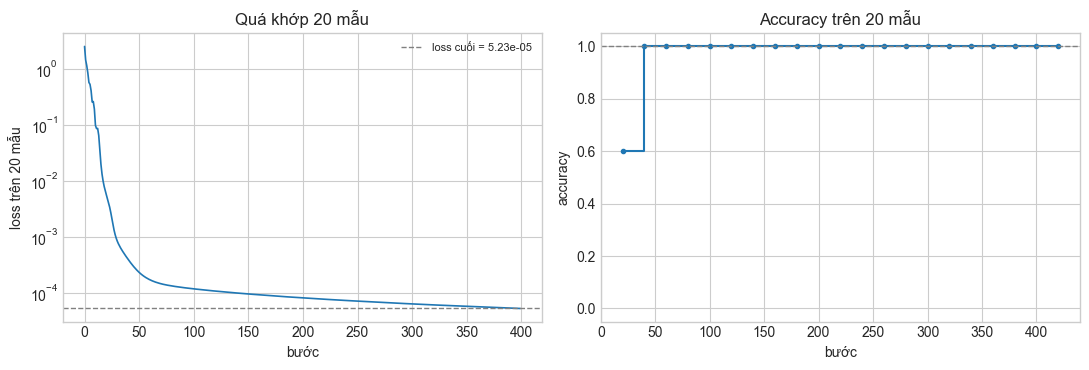

In [6]:
# ---- 1c (tiếp): quá khớp 20 mẫu — loss phải về gần 0 ----
def overfit_test(n_samples=20, steps=400, lr=0.1, seed=1):
    """Quá khớp một lô nhỏ: bằng chứng model + loss + optimizer là đúng."""
    set_seed(seed)
    m = MLP((256, 128), dropout=0.0, init="he").to(device)
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    xb, yb = data["X_tr"][:n_samples], data["y_tr"][:n_samples]
    losses, accs = [], []
    for step in range(1, steps + 1):
        m.train()
        opt.zero_grad(set_to_none=True)
        loss = F.cross_entropy(m(xb), yb)
        loss.backward()
        opt.step()
        losses.append(loss.detach().item())
        if step % 20 == 0 or step == 1:
            accs.append(float((m(xb).argmax(1) == yb).float().mean()))
    return losses, accs

losses, accs = overfit_test()
print(f"quá khớp 20 mẫu (SGD+mom lr=0.1, 400 bước): loss {losses[0]:.4f} -> {losses[-1]:.6f}")
print("accuracy trên 20 mẫu đó theo thời điểm:", [round(a, 3) for a in accs])
assert losses[-1] < 1e-2, "quá khớp 20 mẫu chưa về gần 0 -> gần như chắc chắn lỗi code"

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(losses, lw=1.2); ax[0].set_yscale("log")
ax[0].set_xlabel("bước"); ax[0].set_ylabel("loss trên 20 mẫu"); ax[0].set_title("Quá khớp 20 mẫu")
ax[0].axhline(losses[-1], ls="--", c="gray", lw=1, label=f"loss cuối = {losses[-1]:.2e}")
ax[0].legend(fontsize=8)
ax[1].step(range(20, 20 * len(accs) + 1, 20), accs, where="post", marker="o", ms=3)
ax[1].set_xlabel("bước"); ax[1].set_ylabel("accuracy"); ax[1].set_ylim(-0.05, 1.05)
ax[1].set_title("Accuracy trên 20 mẫu"); ax[1].axhline(1.0, ls="--", c="gray", lw=1)
plt.tight_layout(); plt.show()

In [7]:
# ---- 1d: gradient có chảy tới MỌI tham số không ----
set_seed(1)
m = MLP((256, 128), init="he").to(device)
opt = torch.optim.SGD(m.parameters(), lr=0.05, momentum=0.9)
xb, yb = data["X_tr"][:512], data["y_tr"][:512]
opt.zero_grad(set_to_none=True)
F.cross_entropy(m(xb), yb).backward()

print(f"{'tham số':>12s} {'shape':>12s} {'|grad| L2':>12s}  khác None  khác 0")
ok = True
for name, p in m.named_parameters():
    g = p.grad
    has = g is not None
    nrm = float(g.norm()) if has else float("nan")
    ok &= has and nrm > 0
    print(f"{name:>12s} {str(tuple(p.shape)):>12s} {nrm:12.6f}  {str(has):>9s}  {str(has and nrm > 0):>7s}")
assert ok, "có tham số không nhận được gradient khác 0"
print("\nOK: gradient chảy tới tất cả", sum(1 for _ in m.parameters()), "nhóm tham số.")

     tham số        shape    |grad| L2  khác None  khác 0
net.0.weight    (256, 54)     0.507055       True     True
  net.0.bias       (256,)     0.342240       True     True
net.2.weight   (128, 256)     2.021229       True     True
  net.2.bias       (128,)     0.443874       True     True
net.4.weight     (7, 128)     1.960456       True     True
  net.4.bias         (7,)     0.572456       True     True

OK: gradient chảy tới tất cả 6 nhóm tham số.


**Nhận xét Part 1 (viết lại bằng lời của bạn, chèn số đo ở trên):**

- Số tham số / shape logits: ...
- Loss bước 0 = ... so với `ln 7 = 1.9459`. **Chú ý:** loss bước 0 *không* bằng `ln 7` ngay cả
  khi mô hình "đúng", vì nó phụ thuộc phân bố phương sai của logit lớp cuối. Bảng ở trên cho thấy
  điều đó: khởi tạo He làm logit có phương sai lớn hơn (nên loss cao hơn `ln 7`), còn khởi tạo
  mặc định của `nn.Linear` cho logit nhỏ (loss gần `ln 7`). Vậy tiêu chí đúng là
  **loss bước 0 không quá xa `ln 7` và không phụ thuộc dữ liệu/lớp đa số**; nếu lệch rất xa
  (ví dụ > 0.5) thì kiểm tra lại tỉ lệ `W` lớp cuối, bias, và việc chuẩn hoá đầu vào.
- Quá khớp 20 mẫu: loss ... ; nếu không về gần 0 thì lỗi nằm ở code chứ không phải năng lực mô hình.

---
## Part 2 — Pipeline và baseline

`run_experiment(cfg, data)` là **một hàm duy nhất** cho mọi thí nghiệm: nhận dict cấu hình,
trả về lịch sử mỗi epoch + tóm tắt + `best_state` (epoch có `val_loss` thấp nhất).

Baseline (theo GUIDE): `M-base`, khởi tạo He, cross-entropy, **SGD + momentum 0.9**,
batch 512, **20 epoch**, dropout 0, không clip, FP32. `lr` chọn bằng `val`.

Mỗi epoch ghi: `train_loss` (**đo ở chế độ `eval()`** trên một tập con cố định 50 000 mẫu để
đường train và val cùng thang đo), `val_loss`, `val_acc`, `val_macro_f1`,
`grad_norm` (trung bình / min / max trong epoch, **đo trước khi clip**), thời gian epoch, lr hiện hành.

In [8]:
# ---- Bọc run_experiment: lưu JSON + vẽ ảnh, và bỏ qua nếu đã có kết quả ----
RESULTS = {}

def show_fig(exp_id):
    p = f"{FIGS_DIR}/{exp_id}.png"
    if os.path.isfile(p):
        display(Image(p))

def run_exp(cfg, plot=True):
    """Chạy một thí nghiệm = đổi dict cfg. Lưu results/<exp_id>.json + figures/<exp_id>.png."""
    cfg = {**DEFAULT_CFG, **cfg}
    cfg["hidden"] = tuple(cfg["hidden"])
    cfg["epochs"] = int(cfg["epochs"])
    eid = cfg["exp_id"]
    p = f"{RES_DIR}/{eid}.json"
    if SKIP_DONE and os.path.isfile(p):
        with open(p, encoding="utf-8") as f:
            old = json.load(f)
        old_cfg = {**old["cfg"], "hidden": tuple(old["cfg"]["hidden"])}
        if old_cfg == cfg:
            print(f"  [{eid}] đã có trong results/ và cấu hình không đổi -> bỏ qua")
            RESULTS[eid] = {**old, "best_state": None}
            return RESULTS[eid]
        print(f"  [{eid}] có kết quả cũ nhưng cấu hình đã đổi -> chạy lại")
    res = run_experiment(cfg, data)
    save_result(res, RES_DIR)
    if plot:
        plot_run(res, f"{FIGS_DIR}/{eid}.png")
    RESULTS[eid] = res
    return res

def brief(exp_ids):
    """Bảng tóm tắt nhiều thí nghiệm + chênh lệch so với trung bình baseline và ngưỡng 2σ."""
    base_mean = NOISE["val_macro_f1"]["mean"]
    two_sig = NOISE["val_macro_f1"]["two_sigma"]
    recs = []
    for eid in exp_ids:
        s = RESULTS[eid]["summary"]
        d = s["val_macro_f1"] - base_mean
        recs.append(dict(exp_id=eid, val_macro_f1=round(s["val_macro_f1"], 4),
                         delta_vs_base=round(d, 4),
                         vượt_2σ="Có" if abs(d) > two_sig else "Không",
                         val_acc=round(s["val_acc"], 4),
                         best_val_loss=round(s["best_val_loss"], 4), best_epoch=s["best_epoch"],
                         gap_val_minus_train=round(s["final_val_loss"] - s["final_train_loss"], 4),
                         s_per_epoch=round(s["time_per_epoch_s"], 2),
                         peak_MB=round(s["peak_mem_MB"], 0),
                         diverged="Y" if s["diverged"] else "N"))
    return pd.DataFrame(recs).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

BASE = dict(exp_id="base-s1", group="baseline",
            description=f"Baseline M-base (SGD+mom, He, {EPOCHS} ep)",
            loss="ce", optimizer="sgd_momentum", lr=0.05, weight_decay=0.0, momentum=0.9,
            batch=512, epochs=EPOCHS, hidden=(256, 128), dropout=0.0, init="he",
            clip_norm=None, precision="fp32", scheduler=None, seed=1, notes="")
print("cấu hình baseline chuẩn bị quét lr:")
print({k: BASE[k] for k in ("optimizer", "lr", "batch", "epochs", "hidden", "init", "precision")})

cấu hình baseline chuẩn bị quét lr:
{'optimizer': 'sgd_momentum', 'lr': 0.05, 'batch': 512, 'epochs': 20, 'hidden': (256, 128), 'init': 'he', 'precision': 'fp32'}


In [9]:
# ---- Quét lr cho baseline, chọn bằng VAL ----
LR_SCAN = [0.01, 0.03, 0.1]        # GUIDE: SGD+momentum quanh 0.01–0.1
for lr in LR_SCAN:
    run_exp({**BASE, "exp_id": f"opt-sgdm-lr{lr:g}", "group": "optimizer",
             "description": f"SGD+momentum 0.9, lr = {lr:g}",
             "lr": lr, "notes": "Quét lr trên val; arm SGD+mom của phép so sánh bộ tối ưu."})
scan = pd.DataFrame([dict(lr=lr, val_macro_f1=round(RESULTS[f"opt-sgdm-lr{lr:g}"]["summary"]["val_macro_f1"], 4),
                          val_acc=round(RESULTS[f"opt-sgdm-lr{lr:g}"]["summary"]["val_acc"], 4),
                          best_epoch=RESULTS[f"opt-sgdm-lr{lr:g}"]["summary"]["best_epoch"],
                          s_per_epoch=round(RESULTS[f"opt-sgdm-lr{lr:g}"]["summary"]["time_per_epoch_s"], 2))
                     for lr in LR_SCAN])
display(scan)
BASE_LR = float(scan.loc[scan["val_macro_f1"].idxmax(), "lr"])
print(f"\n==> lr được chọn cho baseline (theo val macro-F1): {BASE_LR:g}")
print("    (chọn bằng val; tập eval chưa vào bước này)")

  [opt-sgdm-lr0.01] ep   1/20  train_loss 0.5774  val_loss 0.5810  val_acc 0.7534  val_f1 0.5070  gbar 4.365e-01  1.5s


  [opt-sgdm-lr0.01] ep   2/20  train_loss 0.5253  val_loss 0.5287  val_acc 0.7773  val_f1 0.5752  gbar 5.021e-01  1.5s


  [opt-sgdm-lr0.01] ep   3/20  train_loss 0.5016  val_loss 0.5046  val_acc 0.7840  val_f1 0.6132  gbar 6.018e-01  1.5s


  [opt-sgdm-lr0.01] ep   4/20  train_loss 0.4743  val_loss 0.4795  val_acc 0.7974  val_f1 0.6403  gbar 6.923e-01  2.0s


  [opt-sgdm-lr0.01] ep   5/20  train_loss 0.4431  val_loss 0.4483  val_acc 0.8100  val_f1 0.6556  gbar 8.013e-01  1.8s


...

  [opt-sgdm-lr0.1] ep  18/20  train_loss 0.2235  val_loss 0.2454  val_acc 0.9022  val_f1 0.8473  gbar 5.592e-01  1.6s


  [opt-sgdm-lr0.1] ep  19/20  train_loss 0.2114  val_loss 0.2327  val_acc 0.9071  val_f1 0.8575  gbar 5.628e-01  1.7s


  [opt-sgdm-lr0.1] ep  20/20  train_loss 0.2160  val_loss 0.2378  val_acc 0.9051  val_f1 0.8543  gbar 5.605e-01  1.5s


,lr,val_macro_f1,val_acc,best_epoch,s_per_epoch
0,0.01,0.7686,0.8707,19,1.72
1,0.03,0.8250,0.8943,19,1.65
2,0.10,0.8575,0.9071,19,1.44



==> lr được chọn cho baseline (theo val macro-F1): 0.1
    (chọn bằng val; tập eval chưa vào bước này)


  [base-s1] ep   1/20  train_loss 0.4677  val_loss 0.4718  val_acc 0.7955  val_f1 0.6487  gbar 5.246e-01  1.5s


  [base-s1] ep   2/20  train_loss 0.3898  val_loss 0.3956  val_acc 0.8363  val_f1 0.6894  gbar 5.680e-01  1.6s


  [base-s1] ep   3/20  train_loss 0.3686  val_loss 0.3729  val_acc 0.8455  val_f1 0.7537  gbar 5.833e-01  1.9s


  [base-s1] ep   4/20  train_loss 0.3571  val_loss 0.3634  val_acc 0.8490  val_f1 0.7511  gbar 5.771e-01  1.4s


  [base-s1] ep   5/20  train_loss 0.3134  val_loss 0.3227  val_acc 0.8647  val_f1 0.7602  gbar 5.854e-01  1.5s


...

  [base-s3] ep  18/20  train_loss 0.2126  val_loss 0.2402  val_acc 0.9044  val_f1 0.8568  gbar 5.675e-01  1.4s


  [base-s3] ep  19/20  train_loss 0.2094  val_loss 0.2381  val_acc 0.9063  val_f1 0.8590  gbar 5.608e-01  1.4s


  [base-s3] ep  20/20  train_loss 0.1979  val_loss 0.2236  val_acc 0.9129  val_f1 0.8603  gbar 5.625e-01  1.4s


ĐỘ NHIỄU GIỮA CÁC SEED của baseline:
  val_macro_f1   các giá trị [0.85749, 0.85655, 0.86025]  TB = 0.85810  σ = 0.00192  2σ = 0.00384
  val_acc        các giá trị [0.90706, 0.91076, 0.91292]  TB = 0.91025  σ = 0.00296  2σ = 0.00593
  best_val_loss  các giá trị [0.2327, 0.22398, 0.22359]  TB = 0.22676  σ = 0.00515  2σ = 0.01030

==> NGƯỠNG NHIỄU 2σ (val macro-F1) = 0.00384
    accuracy 'luôn đoán lớp đa số' trên val = 0.4876  <- mô hình phải vượt


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,base-s3,0.8603,0.0022,Không,0.9129,0.2236,20,0.0257,1.81,174.0,N
1,base-s1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.50,174.0,N
2,base-s2,0.8566,-0.0015,Không,0.9108,0.2240,20,0.0238,1.64,174.0,N


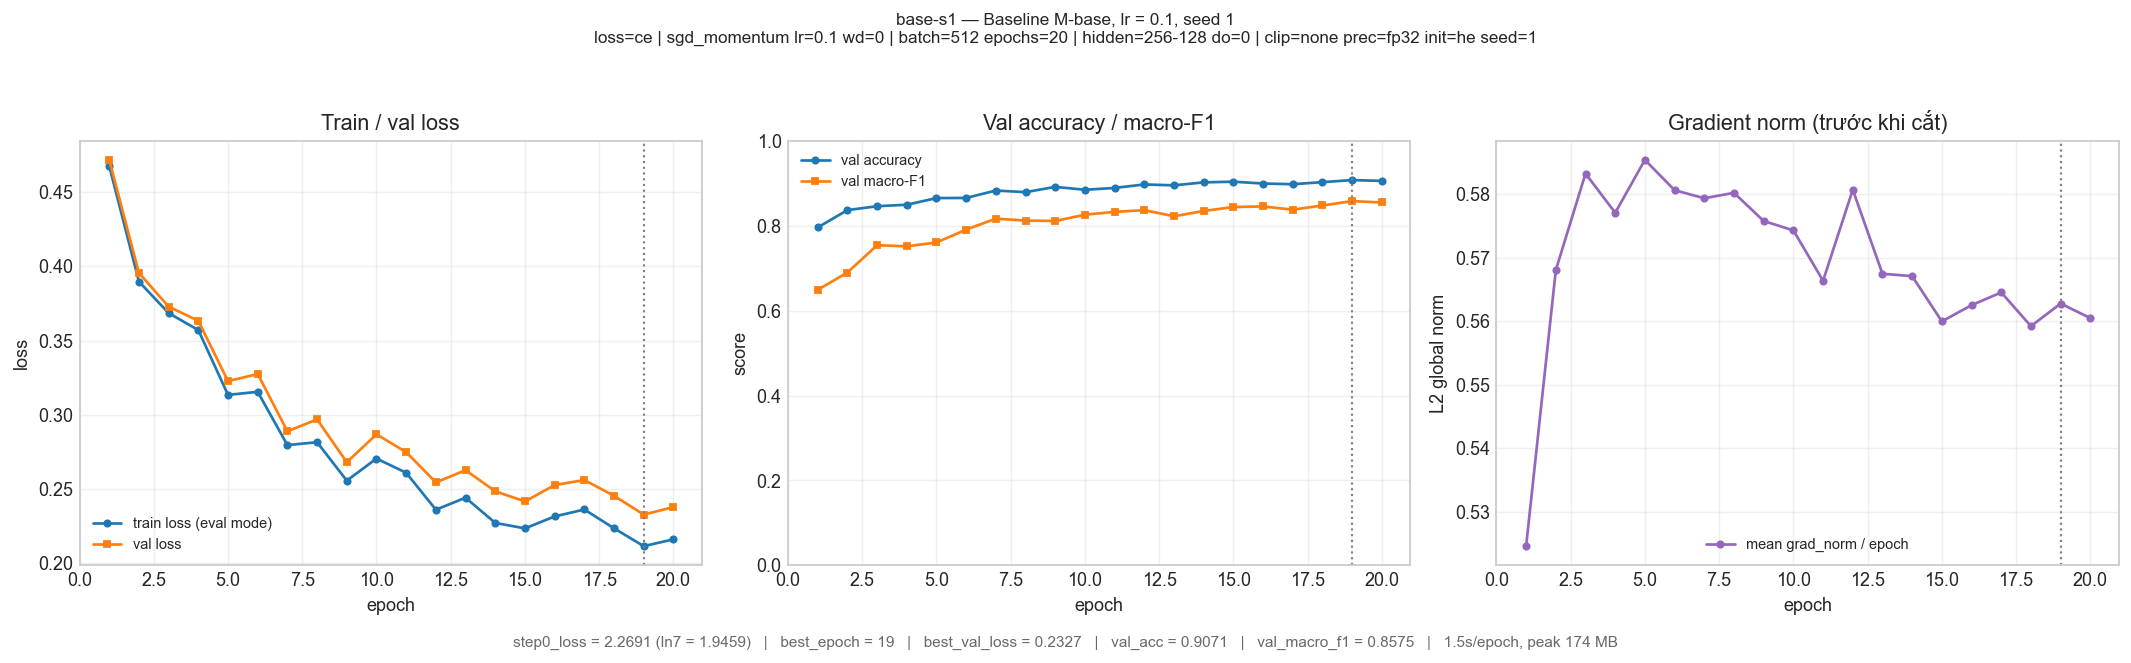

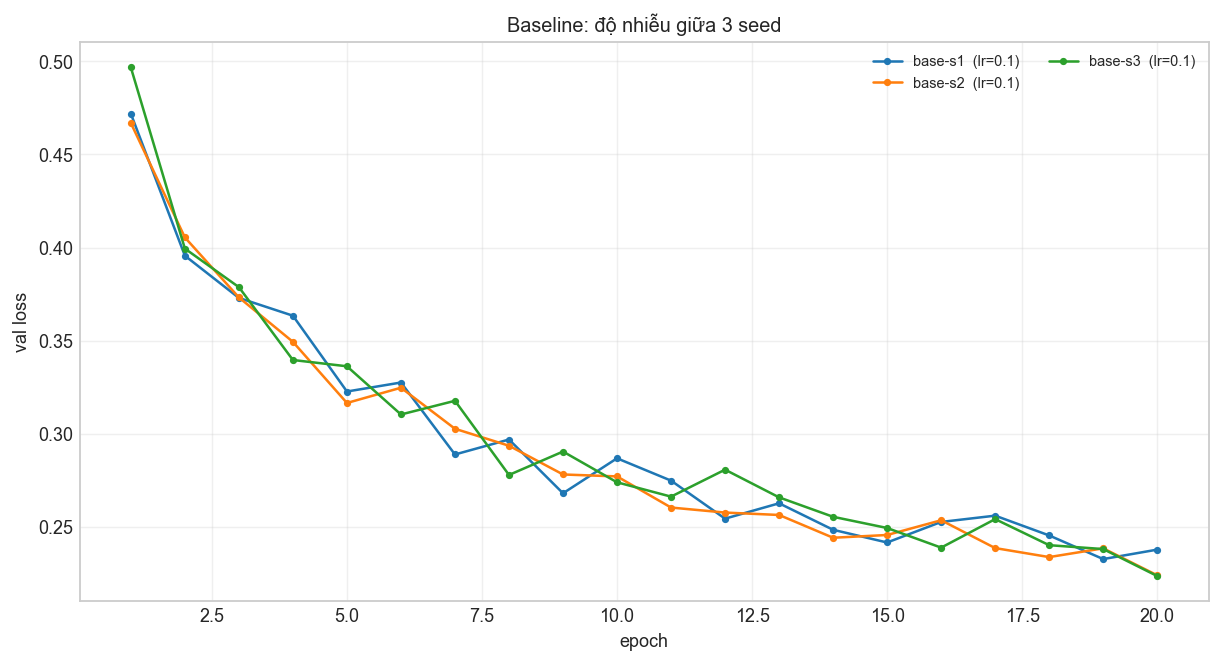

In [10]:
# ---- Baseline với 3 seed để đo độ nhiễu ----
BASE_SEEDS = [1, 2, 3]
for s in BASE_SEEDS:
    run_exp({**BASE, "exp_id": f"base-s{s}", "lr": BASE_LR, "seed": s,
             "description": f"Baseline M-base, lr = {BASE_LR:g}, seed {s}",
             "notes": "Cùng cấu hình, chỉ khác seed -> đo độ nhiễu."})

rows_all = [to_row(RESULTS[e]) for e in RESULTS]
NOISE = noise_stats(rows_all, [f"base-s{s}" for s in BASE_SEEDS])
print("ĐỘ NHIỄU GIỮA CÁC SEED của baseline:")
for m in ("val_macro_f1", "val_acc", "best_val_loss"):
    d = NOISE[m]
    print(f"  {m:14s} các giá trị {[round(v,5) for v in d['values']]}  "
          f"TB = {d['mean']:.5f}  σ = {d['std']:.5f}  2σ = {d['two_sigma']:.5f}")
print(f"\n==> NGƯỠNG NHIỄU 2σ (val macro-F1) = {NOISE['val_macro_f1']['two_sigma']:.5f}")
print(f"    accuracy 'luôn đoán lớp đa số' trên val = {data['majority_acc_val']:.4f}  <- mô hình phải vượt")
display(brief([f"base-s{s}" for s in BASE_SEEDS]))
show_fig("base-s1")
plot_compare([RESULTS[f"base-s{s}"] for s in BASE_SEEDS], "val_loss",
             f"{FIGS_DIR}/compare_seed.png", "Baseline: độ nhiễu giữa 3 seed")
show_fig("compare_seed")

---
## Part 3 — Các thí nghiệm

Mỗi thí nghiệm: **dự đoán trước** (viết ở ô markdown ngay trên) → đổi **một** yếu tố so với
baseline → chạy → **đối chiếu** (ô markdown ngay dưới). Chủ đề trong 7 nhóm:
`loss` · `optimizer` · `hparam` · `dropout` · `clipping` · `amp` · `init`.

Ngưỡng nhiễu dùng để kết luận: **2σ = x.xxxxx** trên `val macro-F1`
(tính ở Part 2 từ 3 seed baseline). Chênh lệch nhỏ hơn 2σ **không phải bằng chứng**.

### 3.1 Hàm mất mát — CE vs MSE

**Dự đoán trước khi chạy.** Ở cùng `lr` và cùng kiến trúc, MSE trên nhãn one-hot sẽ học **chậm hơn**
và cho macro-F1 thấp hơn cross-entropy. Lý do: gradient của CE theo logit là `p − onehot`, tức
`softmax(CE) − y`, sai ở đâu phạt nặng đúng chỗ đó; gradient của MSE là `2/N · (z − y)·σ(z)`,
bị nhân với `σ'(z)` nên **bão hoà** (khi `σ(z)` bão hoà thì gradient gần như triệt tiêu), và
vì không có lũy thừa nên tín hiệu cho lớp hiếm rất yếu. Ngoài ra loss của MSE ở thang khác
(nhỏ hơn nhiều) nên **không được so loss trực tiếp**, phải so accuracy và macro-F1.

  [loss-mse] ep   1/20  train_loss 0.0483  val_loss 0.0485  val_acc 0.7654  val_f1 0.4562  gbar 6.000e-02  2.0s


  [loss-mse] ep   2/20  train_loss 0.0441  val_loss 0.0444  val_acc 0.7864  val_f1 0.5074  gbar 5.611e-02  1.7s


  [loss-mse] ep   3/20  train_loss 0.0420  val_loss 0.0424  val_acc 0.7998  val_f1 0.5459  gbar 6.408e-02  1.6s


  [loss-mse] ep   4/20  train_loss 0.0398  val_loss 0.0403  val_acc 0.8116  val_f1 0.6021  gbar 7.108e-02  1.6s


  [loss-mse] ep   5/20  train_loss 0.0375  val_loss 0.0381  val_acc 0.8227  val_f1 0.6366  gbar 7.835e-02  1.6s


...

  [loss-mse] ep  17/20  train_loss 0.0293  val_loss 0.0303  val_acc 0.8667  val_f1 0.7279  gbar 1.023e-01  1.7s


  [loss-mse] ep  18/20  train_loss 0.0289  val_loss 0.0298  val_acc 0.8692  val_f1 0.7334  gbar 9.884e-02  1.8s


  [loss-mse] ep  19/20  train_loss 0.0287  val_loss 0.0298  val_acc 0.8692  val_f1 0.7379  gbar 1.001e-01  1.8s


  [loss-mse] ep  20/20  train_loss 0.0297  val_loss 0.0306  val_acc 0.8693  val_f1 0.7483  gbar 1.029e-01  1.7s


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,base-s1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.50,174.0,N
1,loss-mse,0.7334,-0.1247,Có,0.8692,0.0298,18,0.0010,1.71,174.0,N


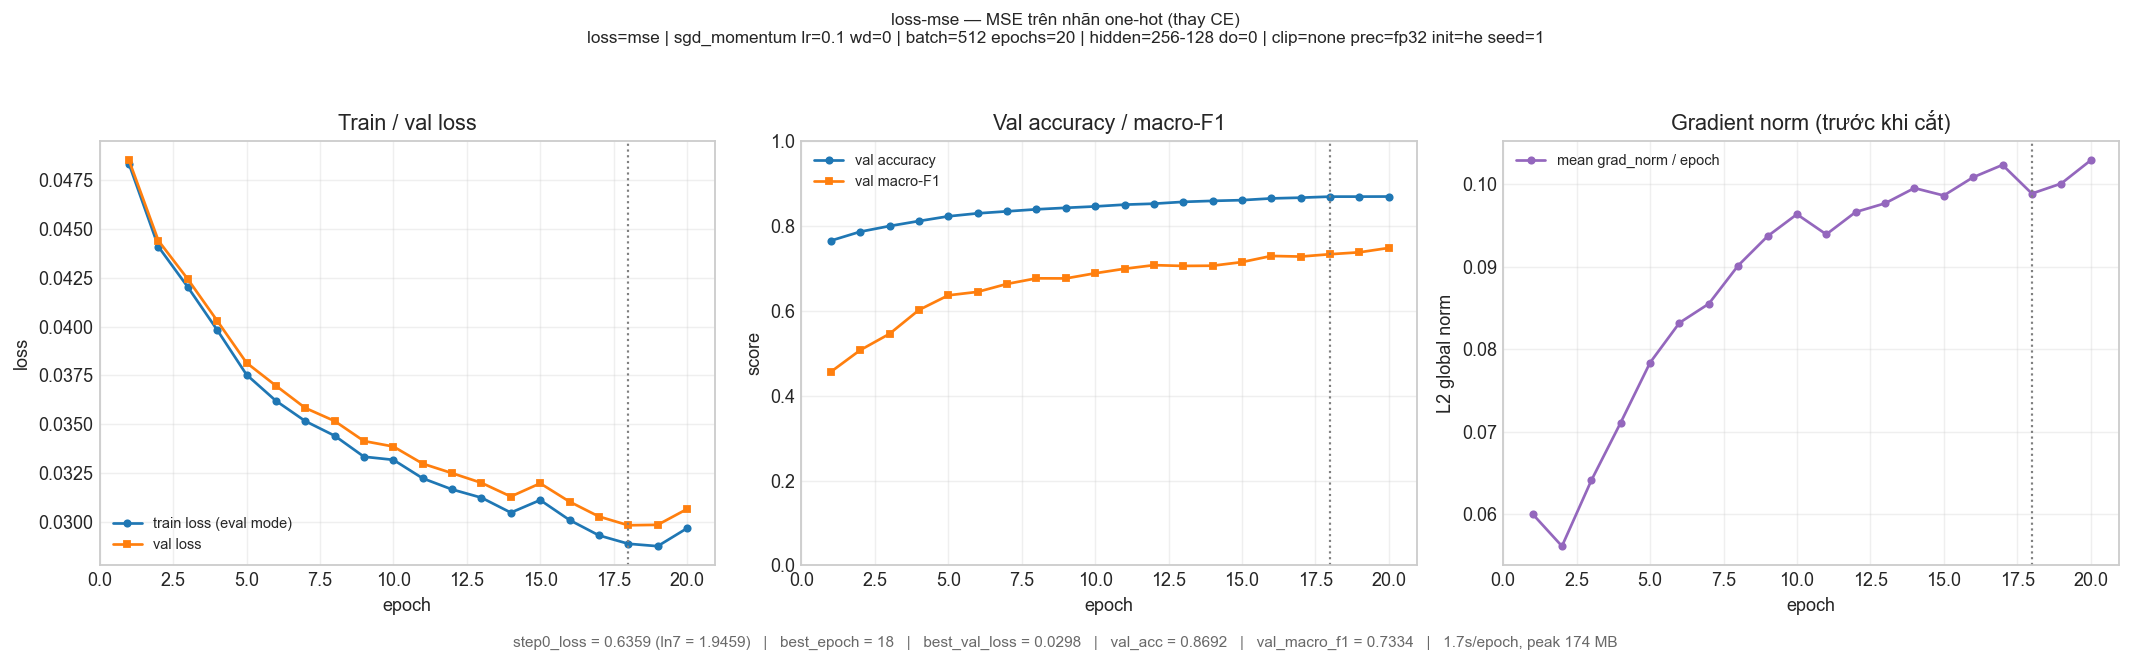

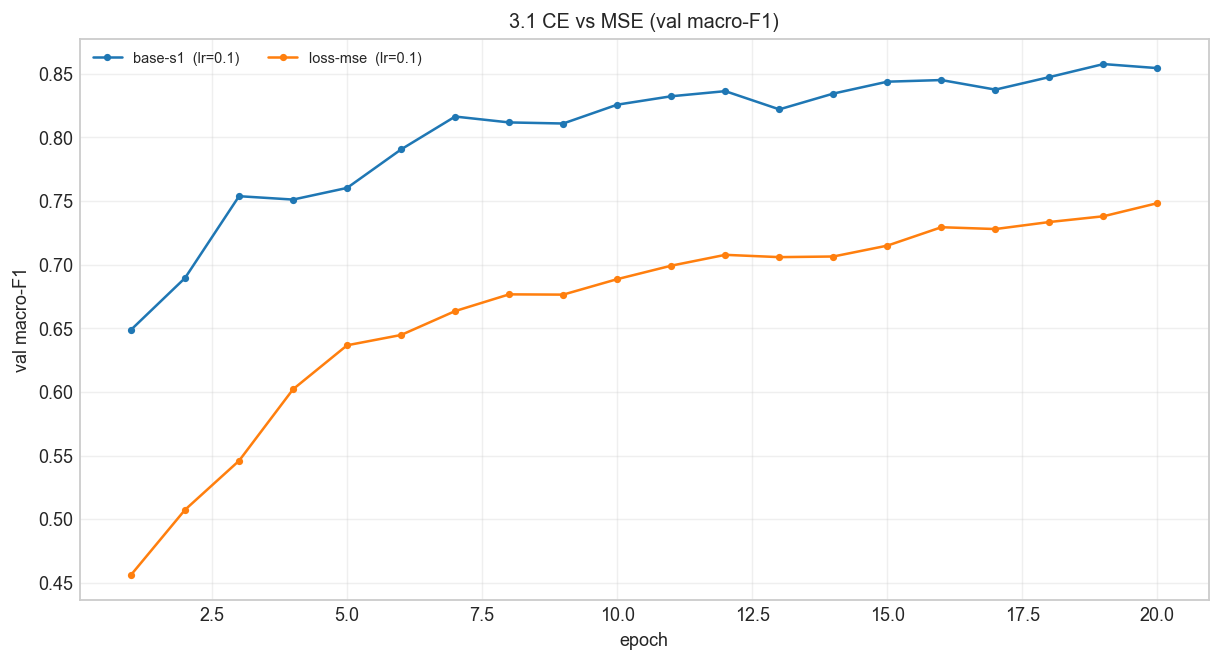

In [11]:
# ---- 3.1 CE (baseline) vs MSE, chỉ đổi đúng yếu tố `loss` ----
run_exp({**BASE, "lr": BASE_LR, "exp_id": "loss-mse", "group": "loss",
         "description": "MSE trên nhãn one-hot (thay CE)", "loss": "mse",
         "notes": "Dự đoán: macro-F1 thấp hơn CE. MSE dùng nn.MSELoss (không hệ số 1/2, "
                  "trung bình trên mọi phần tử B x 7) nên thang đo khác CE — so bằng metric."})
display(brief(["base-s1", "loss-mse"]))
show_fig("loss-mse")
plot_compare([RESULTS["base-s1"], RESULTS["loss-mse"]], "val_macro_f1",
             f"{FIGS_DIR}/compare_loss.png", "3.1 CE vs MSE (val macro-F1)")
show_fig("compare_loss")

**Đối chiếu 3.1.** Xem `compare_loss.png` và cột `delta_vs_base` trong bảng trên: MSE cho
macro-F1 thấp hơn baseline ở cùng `lr` — khớp hay khác dự đoán? Nhớ nhắc: hai loss khác thang đo
(giá trị loss không so được), còn gradient thì MSE bị nhân bởi đạo hàm sigmoid (bão hoà) và
tín hiệu lớp hiếm bị loãng khi chia trung bình trên 7 thành phần.

### 3.2 Bộ tối ưu hoá

**Dự đoán trước khi chạy.** Mỗi bộ tối ưu phải được chỉnh `lr` riêng thì mới so sánh công bằng.
Dự đoán: **Adam/AdamW thắng SGD+SGD+momentum rõ rệt** ở số epoch cố định (20), vì chúng chia bước
theo `m̂/(√v̂+ε)` nên mỗi tham số có bước đi gần như cùng một thang, hội tụ nhanh và ít nhạy `lr` hơn;
ngược lại **SGD nhạy `lr` nhất** và dễ dao động. Ở 20 epoch (chưa hội tụ hẳn) lợi thế hội tụ nhanh
của Adam thường thắng, nhưng khoảng cách sẽ **thu hẹp** khi huấn luyện lâu hơn.
Với `weight_decay = 0`, Adam và AdamW phải cho **cùng** kết quả (cùng công thức, chỉ khác tên chỗ suy giảm trọng số).

  [opt-sgd-lr0.01] ep   1/20  train_loss 0.7602  val_loss 0.7603  val_acc 0.7011  val_f1 0.3200  gbar 4.865e-01  1.6s


  [opt-sgd-lr0.01] ep   2/20  train_loss 0.6809  val_loss 0.6819  val_acc 0.7198  val_f1 0.3804  gbar 3.730e-01  1.5s


  [opt-sgd-lr0.01] ep   3/20  train_loss 0.6467  val_loss 0.6484  val_acc 0.7307  val_f1 0.4228  gbar 3.741e-01  1.4s


  [opt-sgd-lr0.01] ep   4/20  train_loss 0.6261  val_loss 0.6284  val_acc 0.7371  val_f1 0.4467  gbar 3.863e-01  2.0s


  [opt-sgd-lr0.01] ep   5/20  train_loss 0.6118  val_loss 0.6144  val_acc 0.7414  val_f1 0.4702  gbar 3.969e-01  1.6s


...

  [opt-adamw-wd0-lr0.001] ep  18/20  train_loss 0.2247  val_loss 0.2457  val_acc 0.9014  val_f1 0.8402  gbar 1.026e+00  1.4s


  [opt-adamw-wd0-lr0.001] ep  19/20  train_loss 0.2361  val_loss 0.2569  val_acc 0.8971  val_f1 0.8429  gbar 1.036e+00  1.4s


  [opt-adamw-wd0-lr0.001] ep  20/20  train_loss 0.2203  val_loss 0.2412  val_acc 0.9026  val_f1 0.8504  gbar 1.038e+00  1.4s


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,opt-adam-lr0.003,0.8806,0.0225,Có,0.9183,0.2092,20,0.0274,1.56,176.0,N
1,opt-adamw-lr0.003,0.8721,0.0140,Có,0.9148,0.2131,20,0.0247,1.97,176.0,N
2,opt-sgdm-lr0.1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.44,174.0,N
3,opt-adam-lr0.001,0.8504,-0.0077,Có,0.9026,0.2412,20,0.0209,1.53,176.0,N
4,opt-adamw-wd0-lr0.001,0.8504,-0.0077,Có,0.9026,0.2412,20,0.0209,1.62,176.0,N
5,opt-adamw-lr0.001,0.8472,-0.0109,Có,0.9018,0.2460,20,0.0178,1.78,176.0,N
6,opt-sgdm-lr0.03,0.8250,-0.0331,Có,0.8943,0.2634,19,0.0165,1.65,173.0,N
7,opt-adamw-lr0.0003,0.7959,-0.0622,Có,0.8742,0.3126,20,0.0110,1.63,176.0,N
8,opt-adam-lr0.0003,0.7954,-0.0627,Có,0.8737,0.3111,20,0.0114,2.15,175.0,N
9,opt-sgdm-lr0.01,0.7686,-0.0895,Có,0.8707,0.3181,19,0.0117,1.72,173.0,N



So ở lr TỐT NHẤT của từng bộ tối ưu:
  sgd            lr tốt nhất = 0.1      opt-sgd-lr0.1            val macro-F1 = 0.7642  (best epoch 20)
  sgd_momentum   lr tốt nhất = 0.1      opt-sgdm-lr0.1           val macro-F1 = 0.8575  (best epoch 19)
  adam           lr tốt nhất = 0.003    opt-adam-lr0.003         val macro-F1 = 0.8806  (best epoch 20)
  adamw          lr tốt nhất = 0.003    opt-adamw-lr0.003        val macro-F1 = 0.8721  (best epoch 20)

==> Bộ tối ưu thắng (chọn bằng val): adam lr = 0.003 (opt-adam-lr0.003)


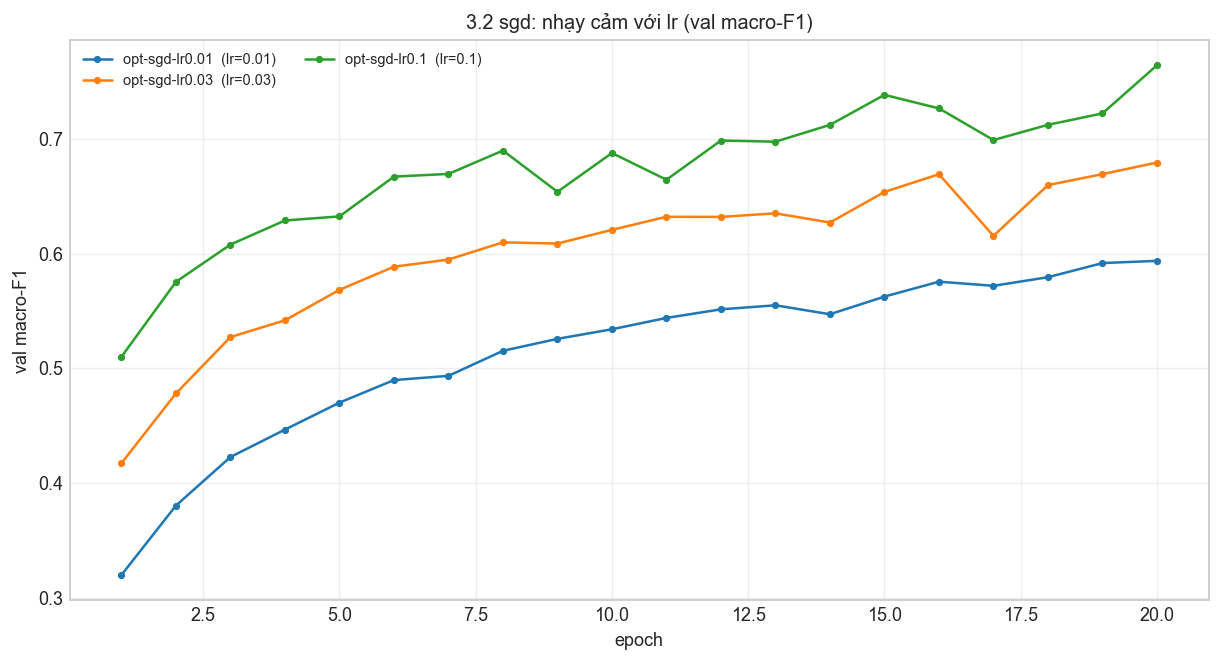

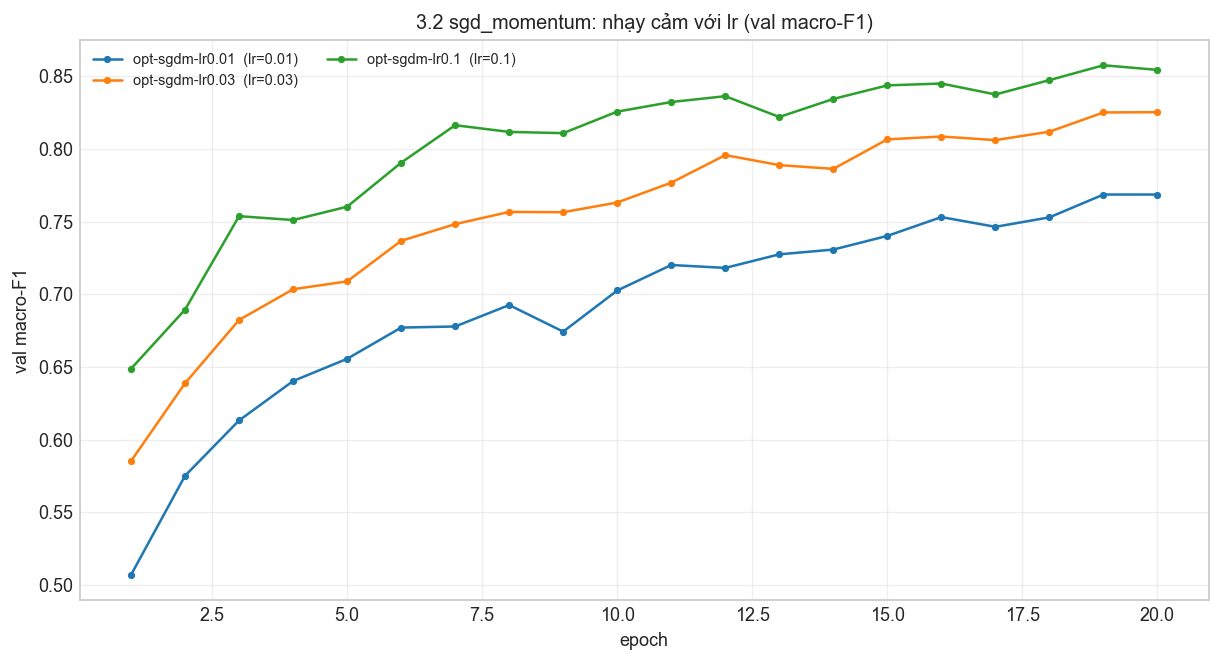

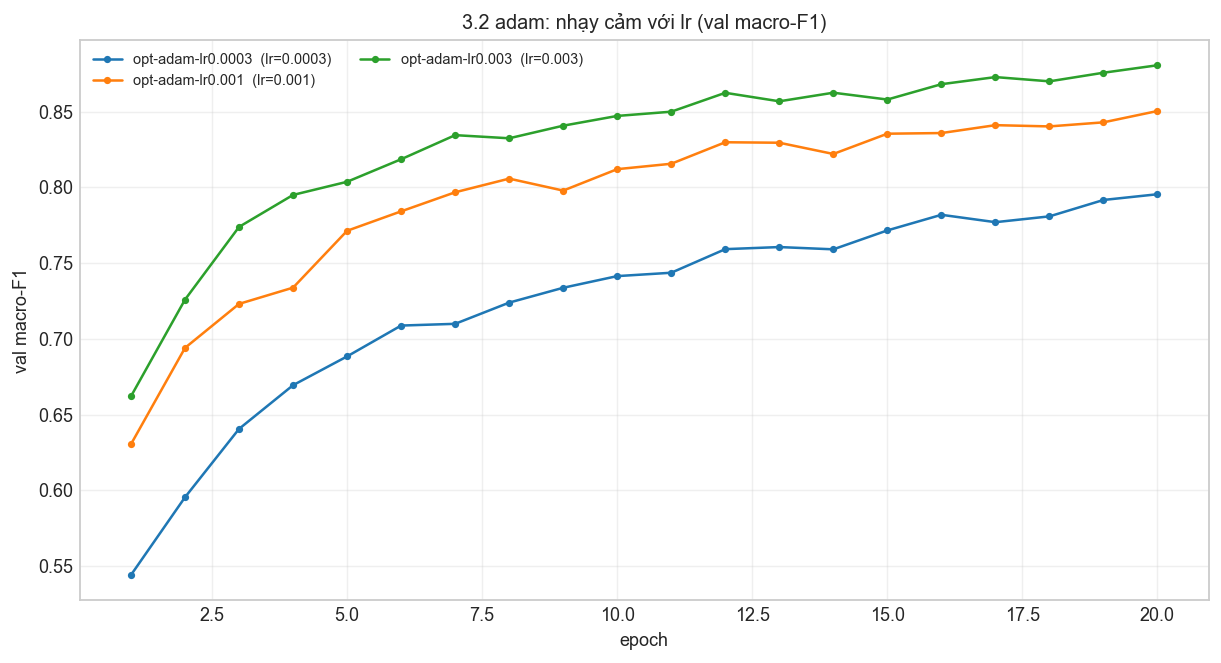

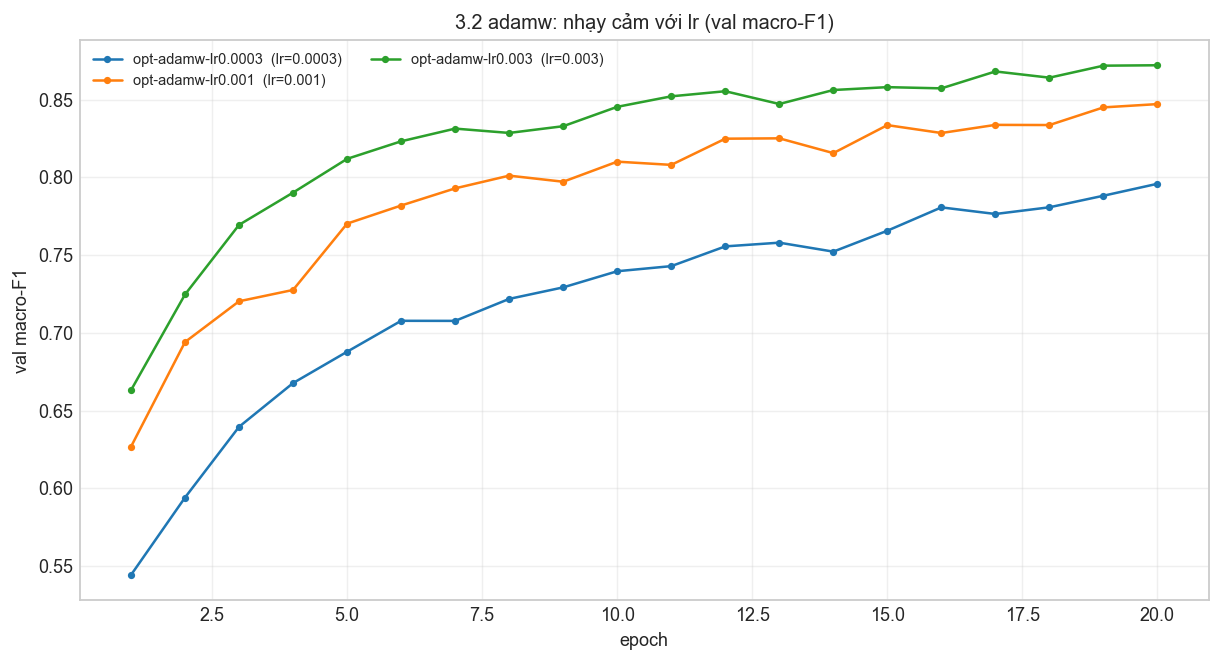

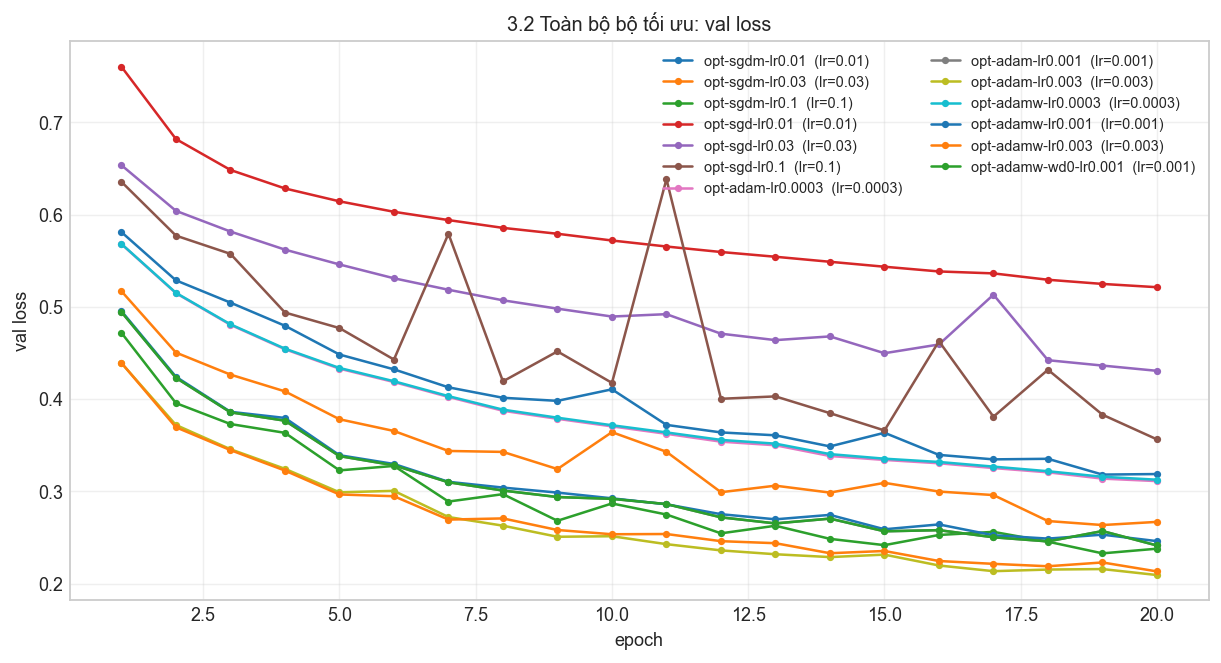

In [12]:
# ---- 3.2 Mỗi bộ tối ưu được thử nhiều lr, rồi so ở lr tốt nhất của chính nó ----
# lr lấy từ GUIDE (khối tham chiếu, chưa kiểm chứng trước): SGD ~0.01–0.1; Adam/AdamW ~1e-4–3e-3
OPT_ARMS = [
    dict(key="sgd",          optimizer="sgd",          lrs=[0.01, 0.03, 0.1],  wd=0.0),
    dict(key="sgd_momentum", optimizer="sgd_momentum", lrs=[0.01, 0.03, 0.1],  wd=0.0),
    dict(key="adam",         optimizer="adam",         lrs=[3e-4, 1e-3, 3e-3], wd=0.0),
    dict(key="adamw",        optimizer="adamw",        lrs=[3e-4, 1e-3, 3e-3], wd=0.01),
]
OPT_PREFIX = {"sgd": "sgd", "sgd_momentum": "sgdm", "adam": "adam", "adamw": "adamw"}

for arm in OPT_ARMS:
    for lr in arm["lrs"]:
        eid = f"opt-{OPT_PREFIX[arm['key']]}-lr{lr:g}"
        if eid in RESULTS:                      # arm SGD+mom đã chạy ở phần quét lr
            continue
        run_exp({**BASE, "lr": BASE_LR, "exp_id": eid, "group": "optimizer",
                 "optimizer": arm["optimizer"], "weight_decay": arm["wd"], "lr": lr,
                 "description": f"{arm['optimizer']} (wd={arm['wd']:g}), lr = {lr:g}",
                 "notes": "So sánh bộ tối ưu: mỗi bộ thử 3 lr cách nhau ~3–10 lần."})

# Kiểm chứng: Adam vs AdamW khi weight_decay = 0 phải cho cùng kết quả
run_exp({**BASE, "lr": BASE_LR, "exp_id": "opt-adamw-wd0-lr0.001", "group": "optimizer",
         "optimizer": "adamw", "weight_decay": 0.0, "lr": 1e-3,
         "description": "AdamW với weight_decay = 0 (kiểm chứng tương đương Adam)",
         "notes": "Với wd=0, Adam và AdamW có cùng công thức cập nhật -> kết quả phải khớp."})

all_opt = [e for e in RESULTS if e.startswith("opt-")]
display(brief(all_opt))

print("\nSo ở lr TỐT NHẤT của từng bộ tối ưu:")
best_per_arm = {}
for arm in OPT_ARMS:
    ids = [f"opt-{OPT_PREFIX[arm['key']]}-lr{lr:g}" for lr in arm["lrs"]]
    ids = [e for e in ids if e in RESULTS]
    b = max(ids, key=lambda e: RESULTS[e]["summary"]["val_macro_f1"])
    best_per_arm[arm["key"]] = b
    print(f"  {arm['optimizer']:<14s} lr tốt nhất = {RESULTS[b]['cfg']['lr']:<8g} "
          f"{b:<24s} val macro-F1 = {RESULTS[b]['summary']['val_macro_f1']:.4f}  "
          f"(best epoch {RESULTS[b]['summary']['best_epoch']})")
BEST_OPT_KEY = max(best_per_arm, key=lambda k: RESULTS[best_per_arm[k]]["summary"]["val_macro_f1"])
BEST_OPT_EID = best_per_arm[BEST_OPT_KEY]
BEST_OPT_CFG = RESULTS[BEST_OPT_EID]["cfg"]
print(f"\n==> Bộ tối ưu thắng (chọn bằng val): {BEST_OPT_CFG['optimizer']} lr = {BEST_OPT_CFG['lr']:g} "
      f"({BEST_OPT_EID})")

for arm in OPT_ARMS:
    ids = [f"opt-{OPT_PREFIX[arm['key']]}-lr{lr:g}" for lr in arm["lrs"] if f"opt-{OPT_PREFIX[arm['key']]}-lr{lr:g}" in RESULTS]
    if len(ids) > 1:
        plot_compare([RESULTS[e] for e in ids], "val_macro_f1", f"{FIGS_DIR}/compare_opt_{arm['key']}.png",
                     f"3.2 {arm['optimizer']}: nhạy cảm với lr (val macro-F1)")
        show_fig(f"compare_opt_{arm['key']}")
plot_compare([RESULTS[e] for e in all_opt], "val_loss", f"{FIGS_DIR}/compare_optimizer.png",
             "3.2 Toàn bộ bộ tối ưu: val loss")
show_fig("compare_optimizer")

**Đối chiếu 3.2.** Điền vào báo cáo: mỗi bộ ở `lr` tốt nhất (bảng in ở trên), độ nhạy với `lr`
(biên độ giữa `lr` tệ nhất và tốt nhất), và cơ chế: SGD có phương sai gradient lớn nên cần `lr` nhỏ
và momentum; Adam chuẩn hoá theo phương sai giới hạn tích cực nên ổn định hơn nhưng bước cập nhật
"không có quy mô" nên hội tụ chậm ở cuối. Ở 20 epoch, epoch tốt nhất có còn là epoch cuối không?

### 3.3 Hyper-parameter

**Dự đoán trước khi chạy.**

- **Batch nhỏ (128)**: nhiều bước cập nhật hơn gấp 4 ở cùng số epoch → học nhanh hơn, nhưng nhiễu
  gradient lớn hơn và tốn thời gian/epoch gấp 4. **Batch lớn (2048)**: ít bước hơn 4 lần → ở cùng
  20 epoch chắc chắn *chưa* hội tụ (best epoch sẽ là epoch cuối), và thường cần tăng `lr` để bù
  (quy tắc lô ×k thì η ×k) — ta giữ nguyên `lr` để cô lập đúng một yếu tố.
- **Độ rộng / độ sâu**: `M-wide` (161k tham số) nên vẫn dưới-khớp ở 20 epoch → dự đoán tốt hơn
  `M-base`; `M-deep` thêm ít tham số nên gần như không khác.
- **Cosine annealing**: giảm `lr` về 0 giúp "hạ cánh" nên thường cải thiện một chút ở ngân sách epoch cố định.
- **Huấn luyện lâu hơn (60 epoch)**: vì ở 20 epoch đường val loss vẫn còn giảm (best epoch = epoch cuối),
  chạy lâu hơn phải cho macro-F1 cao hơn rõ rệt — đây là bằng chứng mô hình **chưa** hội tụ chứ không phải quá khớp.

  [hparam-batch128] ep   1/20  train_loss 0.4272  val_loss 0.4300  val_acc 0.8196  val_f1 0.6923  gbar 5.890e-01  5.6s


  [hparam-batch128] ep   2/20  train_loss 0.3809  val_loss 0.3895  val_acc 0.8397  val_f1 0.7295  gbar 5.932e-01  5.0s


  [hparam-batch128] ep   3/20  train_loss 0.3273  val_loss 0.3410  val_acc 0.8589  val_f1 0.7769  gbar 5.995e-01  5.5s


  [hparam-batch128] ep   4/20  train_loss 0.3093  val_loss 0.3194  val_acc 0.8712  val_f1 0.7855  gbar 6.012e-01  5.5s


  [hparam-batch128] ep   5/20  train_loss 0.2806  val_loss 0.2965  val_acc 0.8789  val_f1 0.8077  gbar 6.015e-01  5.9s


...

  [hparam-epoch60] ep  57/60  train_loss 0.1443  val_loss 0.1827  val_acc 0.9302  val_f1 0.8863  gbar 5.285e-01  1.2s


  [hparam-epoch60] ep  58/60  train_loss 0.1791  val_loss 0.2175  val_acc 0.9190  val_f1 0.8721  gbar 5.385e-01  1.4s


  [hparam-epoch60] ep  59/60  train_loss 0.1651  val_loss 0.2046  val_acc 0.9227  val_f1 0.8762  gbar 5.476e-01  1.1s


  [hparam-epoch60] ep  60/60  train_loss 0.1530  val_loss 0.1953  val_acc 0.9258  val_f1 0.8807  gbar 5.292e-01  1.3s


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,hparam-epoch60,0.8863,0.0282,Có,0.9302,0.1827,57,0.0423,1.36,178.0,N
1,arch-wide,0.8778,0.0197,Có,0.9204,0.2042,20,0.0300,1.41,195.0,N
2,arch-deep,0.8733,0.0152,Có,0.9198,0.2015,20,0.0274,1.69,178.0,N
3,hparam-cosine,0.8660,0.0079,Có,0.9208,0.2016,20,0.0243,1.51,177.0,N
4,hparam-batch128,0.8609,0.0028,Không,0.9135,0.2191,20,0.0266,8.06,176.0,N
5,base-s1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.50,174.0,N
6,hparam-wd1e-4,0.8367,-0.0214,Có,0.8950,0.2644,19,0.0144,1.45,177.0,N
7,hparam-batch2048,0.8187,-0.0394,Có,0.8871,0.2773,20,0.0131,0.38,177.0,N


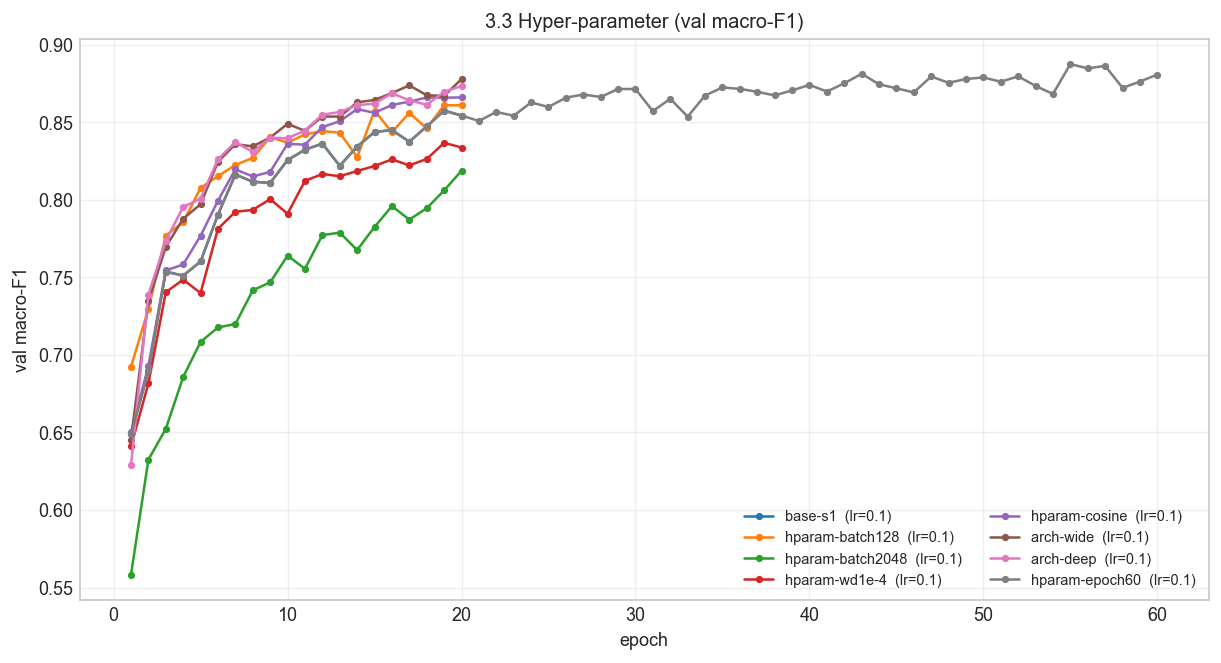

In [13]:
# ---- 3.3 Hyper-parameter: mỗi lần chỉ đổi MỘT yếu tố ----
HPARAMS = [
    dict(exp_id="hparam-batch128",  description="Batch size 128 (thay 512)",        batch=128),
    dict(exp_id="hparam-batch2048", description="Batch size 2048 (thay 512)",       batch=2048),
    dict(exp_id="hparam-wd1e-4",    description="weight_decay 1e-4 (thay 0)",        weight_decay=1e-4),
    dict(exp_id="hparam-cosine",    description="Cosine annealing theo bước",       scheduler="cosine"),
    dict(exp_id="arch-wide",        description="M-wide 54->512->256->7",            hidden=(512, 256)),
    dict(exp_id="arch-deep",        description="M-deep 54->256->128->64->7",        hidden=(256, 128, 64)),
    dict(exp_id="hparam-epoch%d" % EPOCHS_LONG,
         description=f"{EPOCHS_LONG} epoch (thay {EPOCHS}) — kiểm tra mô hình đã hội tụ chưa",
         epochs=EPOCHS_LONG),
]
for h_ in HPARAMS:
    run_exp({**BASE, "lr": BASE_LR, "group": "hparam", **h_,
             "notes": "Chỉ đổi một yếu tố so với baseline (lr giữ nguyên). "
                      "Số epoch khác nghĩa là số bước cập nhật khác — cần nhớ khi giải thích."})

display(brief(["base-s1"] + [h_["exp_id"] for h_ in HPARAMS if h_["exp_id"] in RESULTS]))
plot_compare([RESULTS["base-s1"]] + [RESULTS[h_["exp_id"]] for h_ in HPARAMS if h_["exp_id"] in RESULTS],
             "val_macro_f1", f"{FIGS_DIR}/compare_hparam.png", "3.3 Hyper-parameter (val macro-F1)")
show_fig("compare_hparam")

**Đối chiếu 3.3.** Nhớ phân biệt **số bước cập nhật**: `371847/128 ≈ 2904` bước/epoch so với
`182` bước/epoch ở batch 2048 — cùng 20 epoch nhưng khác số bước rất xa, nên so sánh phải tính cả
thời gian/epoch (`s_per_epoch`) và số bước. `M-wide`/`M-deep` đổi **kiến trúc** (số tham số khác
hẳn) — đó là "một yếu tố" ở đây. Với `hparam-epoch*`: best epoch có còn là epoch cuối không, và
khoảng cách `val_loss − train_loss` có tăng (dấu hiệu bắt đầu quá khớp) không?

### 3.4 Dropout

**Dự đoán trước khi chạy.** Ở 20 epoch trên tập 371k mẫu với mạng chỉ 48k tham số, mô hình
**chưa quá khớp** (khoảng cách `val_loss − train_loss` còn nhỏ), nên dropout `q = 0.3` và `q = 0.5`
nhiều khả năng **không giúp** và còn làm chậm hội tụ; chỉ `q` rất nhỏ (`0.1`) là ứng viên hợp lý.
Đây là bài học: dropout là **thuốc cho quá khớp**, dùng khi đã có bằng chứng quá khớp.

  [drop-0.1] ep   1/20  train_loss 0.4874  val_loss 0.4913  val_acc 0.7873  val_f1 0.6085  gbar 4.006e-01  1.3s


  [drop-0.1] ep   2/20  train_loss 0.4221  val_loss 0.4276  val_acc 0.8151  val_f1 0.6716  gbar 3.667e-01  1.4s


  [drop-0.1] ep   3/20  train_loss 0.3982  val_loss 0.4013  val_acc 0.8259  val_f1 0.7087  gbar 3.711e-01  1.9s


  [drop-0.1] ep   4/20  train_loss 0.3683  val_loss 0.3730  val_acc 0.8439  val_f1 0.7289  gbar 3.753e-01  2.0s


  [drop-0.1] ep   5/20  train_loss 0.3474  val_loss 0.3517  val_acc 0.8553  val_f1 0.7568  gbar 3.826e-01  1.9s


...

  [drop-0.5] ep  17/20  train_loss 0.4019  val_loss 0.4056  val_acc 0.8293  val_f1 0.6831  gbar 3.619e-01  1.4s


  [drop-0.5] ep  18/20  train_loss 0.4004  val_loss 0.4029  val_acc 0.8319  val_f1 0.6512  gbar 3.621e-01  1.4s


  [drop-0.5] ep  19/20  train_loss 0.3934  val_loss 0.3970  val_acc 0.8306  val_f1 0.6976  gbar 3.616e-01  1.6s


  [drop-0.5] ep  20/20  train_loss 0.3941  val_loss 0.3962  val_acc 0.8313  val_f1 0.6850  gbar 3.606e-01  1.5s


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,base-s1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.50,174.0,N
1,drop-0.1,0.8452,-0.0129,Có,0.9012,0.2468,20,0.0117,1.73,178.0,N
2,drop-0.2,0.8166,-0.0415,Có,0.8883,0.2788,20,0.0084,1.83,178.0,N
3,drop-0.5,0.6850,-0.1731,Có,0.8313,0.3962,20,0.0021,1.52,179.0,N


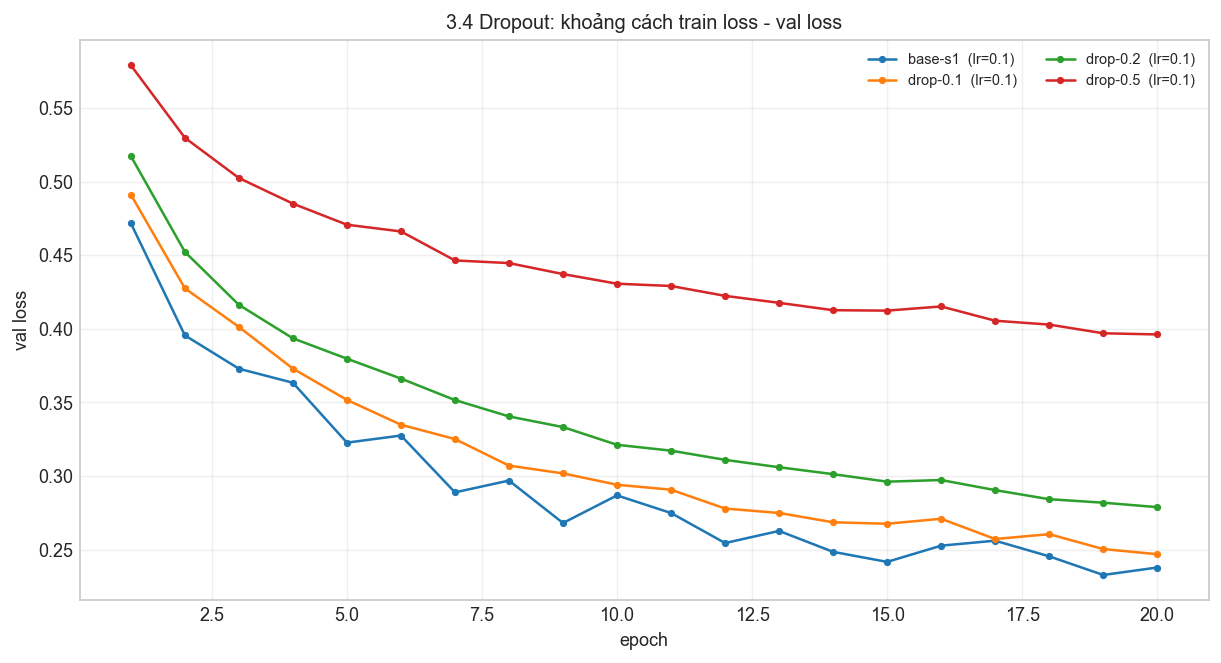

In [14]:
# ---- 3.4 Dropout: q = 0.1 / 0.2 / 0.5 (baseline q = 0) ----
run_exp({**BASE, "lr": BASE_LR, "exp_id": "drop-0.1", "group": "dropout", "dropout": 0.1,
         "description": "Dropout q = 0.1", "notes": "Dự đoán: q nhỏ có thể giúp nhẹ."})
run_exp({**BASE, "lr": BASE_LR, "exp_id": "drop-0.2", "group": "dropout", "dropout": 0.2,
         "description": "Dropout q = 0.2",
         "notes": "Dự đoán: không giúp vì mô hình chưa quá khớp."})
run_exp({**BASE, "lr": BASE_LR, "exp_id": "drop-0.5", "group": "dropout", "dropout": 0.5,
         "description": "Dropout q = 0.5",
         "notes": "Dự đoán: quá mạnh, macro-F1 giảm rõ."})

display(brief(["base-s1", "drop-0.1", "drop-0.2", "drop-0.5"]))
plot_compare([RESULTS[e] for e in ("base-s1", "drop-0.1", "drop-0.2", "drop-0.5")],
             "val_loss", f"{FIGS_DIR}/compare_dropout.png",
             "3.4 Dropout: khoảng cách train loss - val loss")
show_fig("compare_dropout")

**Đối chiếu 3.4.** Vẽ chồng cho thấy khoảng cách `train_loss` (đo ở `eval()`) với `val_loss`
**hẹp lại hay rộng ra** khi tăng `q`. Lưu ý: nếu bạn đo train loss **trong lúc huấn luyện** (dropout
đang bật) thì sẽ thấy dropout "làm tăng train loss" một cách giả — đó chỉ là hiệu ứng tắt nơ-ron.

### 3.5 Cắt gradient

`g ← g · min(1, c/‖g‖)` với `‖g‖` là chuẩn L2 **toàn cục** của mọi gradient gộp lại.

**Dự đoán trước khi chạy.** Ở `lr` của baseline, `‖g‖` ổn định và nhỏ hơn 1, nên chọn `c = 1.0`
sẽ **không** (hoặc rất hiếm khi) kích hoạt → chênh lệch so với baseline chỉ là nhiễu, và đó chính là
kết quả đúng đắn phải báo cáo. Vì thế thí nghiệm **phản chứng** mới là thứ chứng minh clipping có ích:
tăng `lr` lên `10 × lr` cho tới khi gradient nổ gai và loss dao động/NaN, rồi chạy lại **cùng lr đó
có clip**. Dự đoán: không clip thì loss phá vỡ (NaN hoặc macro-F1 về mức đoán đa số), có clip thì vẫn học được.

grad_norm của baseline (đo TRƯỚC khi clip):
  theo epoch — min 0.214 / trung vị 0.569 / max 2.905
  trung vị của trung bình epoch: 0.568;  p90 của max trong epoch: 1.236

==> chọn c = 1: trong 85% epoch có ít nhất một phần bước bị cắt (epoch có min < c < max).
    Nếu c lớn hơn mọi grad_norm thì clipping không làm gì cả — kết luận 'không khác' chỉ là nhiễu.


  [clip-1.0] ep   1/20  train_loss 0.4622  val_loss 0.4659  val_acc 0.7996  val_f1 0.6456  gbar 5.322e-01  1.3s


  [clip-1.0] ep   2/20  train_loss 0.4031  val_loss 0.4109  val_acc 0.8325  val_f1 0.6847  gbar 5.670e-01  1.4s


  [clip-1.0] ep   3/20  train_loss 0.3663  val_loss 0.3726  val_acc 0.8423  val_f1 0.7503  gbar 5.830e-01  1.5s


  [clip-1.0] ep   4/20  train_loss 0.3489  val_loss 0.3552  val_acc 0.8506  val_f1 0.7596  gbar 5.791e-01  1.4s


...

  [clip-hilr-clip1.0] ep  17/20  train_loss 0.3181  val_loss 0.3385  val_acc 0.8734  val_f1 0.7845  gbar 2.497e-01  1.3s


  [clip-hilr-clip1.0] ep  18/20  train_loss 0.3134  val_loss 0.3332  val_acc 0.8726  val_f1 0.7985  gbar 2.435e-01  1.3s


  [clip-hilr-clip1.0] ep  19/20  train_loss 0.3198  val_loss 0.3414  val_acc 0.8701  val_f1 0.8008  gbar 2.464e-01  1.3s


  [clip-hilr-clip1.0] ep  20/20  train_loss 0.2795  val_loss 0.3057  val_acc 0.8860  val_f1 0.8151  gbar 2.439e-01  1.3s


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,base-s1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.50,174.0,N
1,clip-1.0,0.8530,-0.0051,Có,0.9076,0.2308,19,0.0221,1.35,179.0,N
2,clip-hilr-clip1.0,0.8151,-0.0430,Có,0.8860,0.3057,20,0.0262,1.44,179.0,N
3,clip-hilr-noclip,0.6276,-0.2305,Có,0.8472,0.3835,15,0.0092,1.38,179.0,N


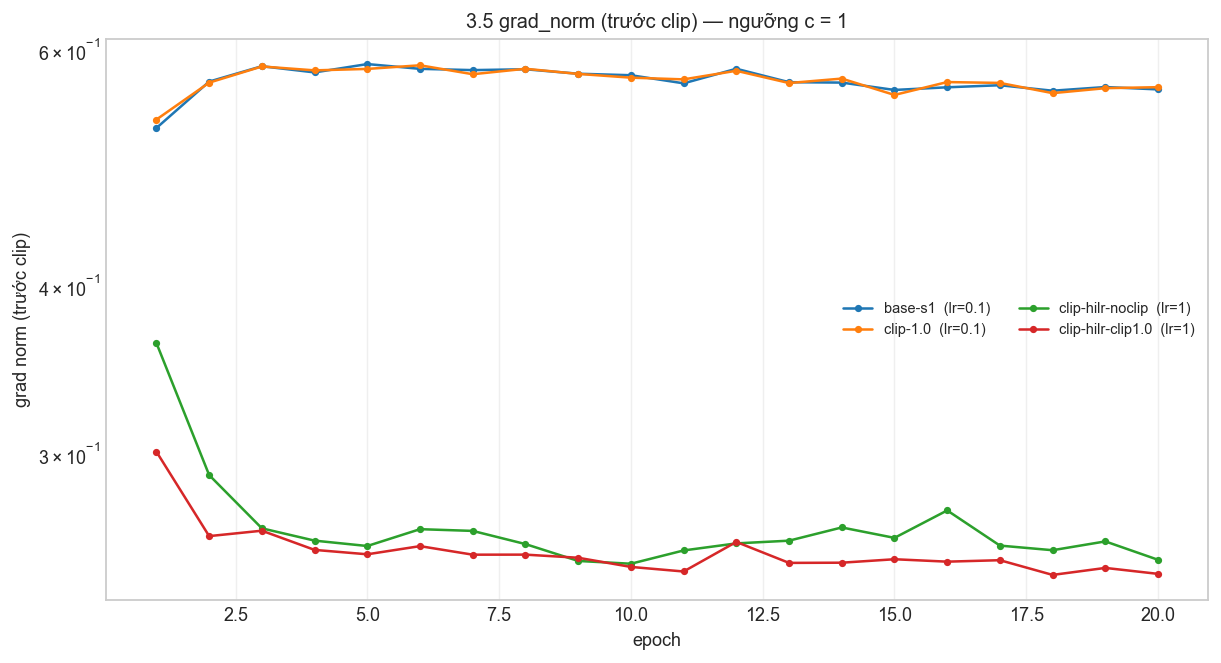

In [15]:
# ---- 3.5 Chọn c dựa trên grad_norm quan sát được ở baseline ----
h0 = RESULTS["base-s1"]["history"]
gn_mean = np.array(h0["grad_norm"]); gn_max = np.array(h0["grad_norm_max"]); gn_min = np.array(h0["grad_norm_min"])
print("grad_norm của baseline (đo TRƯỚC khi clip):")
print(f"  theo epoch — min {gn_min.min():.3f} / trung vị {gn_mean.mean():.3f} / max {gn_max.max():.3f}")
print(f"  trung vị của trung bình epoch: {np.median(gn_mean):.3f};  p90 của max trong epoch: {np.percentile(gn_max, 90):.3f}")

CLIP_C = 1.0
frac = float(((gn_min < CLIP_C) & (gn_max > CLIP_C)).mean())
print(f"\n==> chọn c = {CLIP_C:g}: trong {100*frac:.0f}% epoch có ít nhất một phần bước bị cắt "
      f"(epoch có min < c < max).")
print("    Nếu c lớn hơn mọi grad_norm thì clipping không làm gì cả — kết luận 'không khác' chỉ là nhiễu.")

run_exp({**BASE, "lr": BASE_LR, "exp_id": "clip-1.0", "group": "clipping", "clip_norm": CLIP_C,
         "description": f"Gradient clipping c = {CLIP_C:g} ở lr baseline",
         "notes": f"Dự đoán: clipping hiếm khi kích hoạt ở lr thường nên chênh lệch chỉ là nhiễu. c={CLIP_C:g} chọn từ grad_norm của baseline."})

# --- thí nghiệm phản chứng: lr cao, có clip và không clip
HIGH_LR_MULT = 10
HIGH_LR = BASE_LR * HIGH_LR_MULT
run_exp({**BASE, "lr": HIGH_LR, "exp_id": "clip-hilr-noclip", "group": "clipping",
         "description": f"lr cao {HIGH_LR:g} (= {HIGH_LR_MULT}×lr baseline), KHÔNG clip",
         "notes": "Phản chứng: gradient nổ gai ở lr cao, kỳ vọng loss dao động/NaN."})
run_exp({**BASE, "lr": HIGH_LR, "exp_id": "clip-hilr-clip1.0", "group": "clipping", "clip_norm": CLIP_C,
         "description": f"lr cao {HIGH_LR:g} (= {HIGH_LR_MULT}×lr baseline), CÓ clip c = {CLIP_C:g}",
         "notes": "Cùng lr cao nhưng có clip — so với 'clip-hilr-noclip' để thấy vai trò của clipping."})

display(brief(["base-s1", "clip-1.0", "clip-hilr-noclip", "clip-hilr-clip1.0"]))
plot_compare([RESULTS[e] for e in ("base-s1", "clip-1.0", "clip-hilr-noclip", "clip-hilr-clip1.0")],
             "grad_norm", f"{FIGS_DIR}/compare_clipping.png",
             f"3.5 grad_norm (trước clip) — ngưỡng c = {CLIP_C:g}")
show_fig("compare_clipping")

**Đối chiếu 3.5.** Ở `lr` thường, clipping có kích hoạt không (dựa vào `grad_norm`) và chênh lệch có
vượt 2σ không — nếu không vượt, kết luận phải là "clipping không có tác dụng ở `lr` này", **không phải**
"clipping vô dụng". Ở `lr` cao: cột `diverged` và đường `grad_norm` (thang log) cho thấy cắt gradient
cứu được huấn luyện ra sao — cơ chế là bước cập nhật không bao giờ vượt quá `c·lr` theo mỗi hướng.

### 3.6 Mixed precision

FP16 dùng `torch.autocast(dtype=torch.float16)` + `GradScaler`; BF16 dùng `dtype=torch.bfloat16`
(thường **không** cần `GradScaler`). Tham số vẫn FP32 — autocast chỉ hạ độ chính xác phép toán.

**Dự đoán trước khi chạy.** Với mạng **rất nhỏ** (48k tham số, batch 512), thời gian mỗi bước bị
chi phối bởi **chi phí gọi kernel và chuyển đổi dtype**, không phải FLOPs → mixed precision có thể
**không nhanh hơn** (thậm chí chậm hơn) FP32. Bộ nhớ GPU giảm nhẹ. Chất lượng phải gần như không đổi.
FP16 cần `GradScaler` vì dải số động của FP16 hẹp (~5·10⁻⁵ … 65504): gradient rất nhỏ sẽ tràn về 0,
nên loss phải được nhân với hệ số scale rồi bỏ scale trước khi cắt gradient. BF16 có cùng độ rộng
thập phân như FP32 (8 bit mantissa) nên không cần scale.

  [amp-fp16] ep   1/20  train_loss 0.4620  val_loss 0.4653  val_acc 0.7998  val_f1 0.6502  gbar 5.296e-01  2.3s


  [amp-fp16] ep   2/20  train_loss 0.3919  val_loss 0.3977  val_acc 0.8351  val_f1 0.6984  gbar 5.630e-01  2.0s


  [amp-fp16] ep   3/20  train_loss 0.3696  val_loss 0.3737  val_acc 0.8441  val_f1 0.7472  gbar 5.819e-01  1.9s


  [amp-fp16] ep   4/20  train_loss 0.3575  val_loss 0.3629  val_acc 0.8482  val_f1 0.7512  gbar 5.724e-01  1.8s


  [amp-fp16] ep   5/20  train_loss 0.3161  val_loss 0.3231  val_acc 0.8670  val_f1 0.7447  gbar 5.782e-01  1.9s


...

  [amp-bf16] ep  18/20  train_loss 0.2221  val_loss 0.2457  val_acc 0.9007  val_f1 0.8353  gbar 5.588e-01  1.9s


  [amp-bf16] ep  19/20  train_loss 0.2135  val_loss 0.2354  val_acc 0.9063  val_f1 0.8488  gbar 5.546e-01  1.7s


  [amp-bf16] ep  20/20  train_loss 0.2064  val_loss 0.2280  val_acc 0.9101  val_f1 0.8569  gbar 5.578e-01  1.8s


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,amp-fp16,0.8626,0.0045,Có,0.9103,0.2240,20,0.0244,2.03,179.0,N
1,base-s1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.50,174.0,N
2,amp-bf16,0.8569,-0.0012,Không,0.9101,0.2280,20,0.0216,1.65,179.0,N



Thời gian / bộ nhớ / độ chính xác so với FP32:
  amp-fp16     2.03 s/epoch ( 1.36× fp32) | peak  179.3 MB ( 1.03×) | val macro-F1 0.8626 (Δ = +0.0051)
  amp-bf16     1.65 s/epoch ( 1.10× fp32) | peak  179.4 MB ( 1.03×) | val macro-F1 0.8569 (Δ = -0.0006)


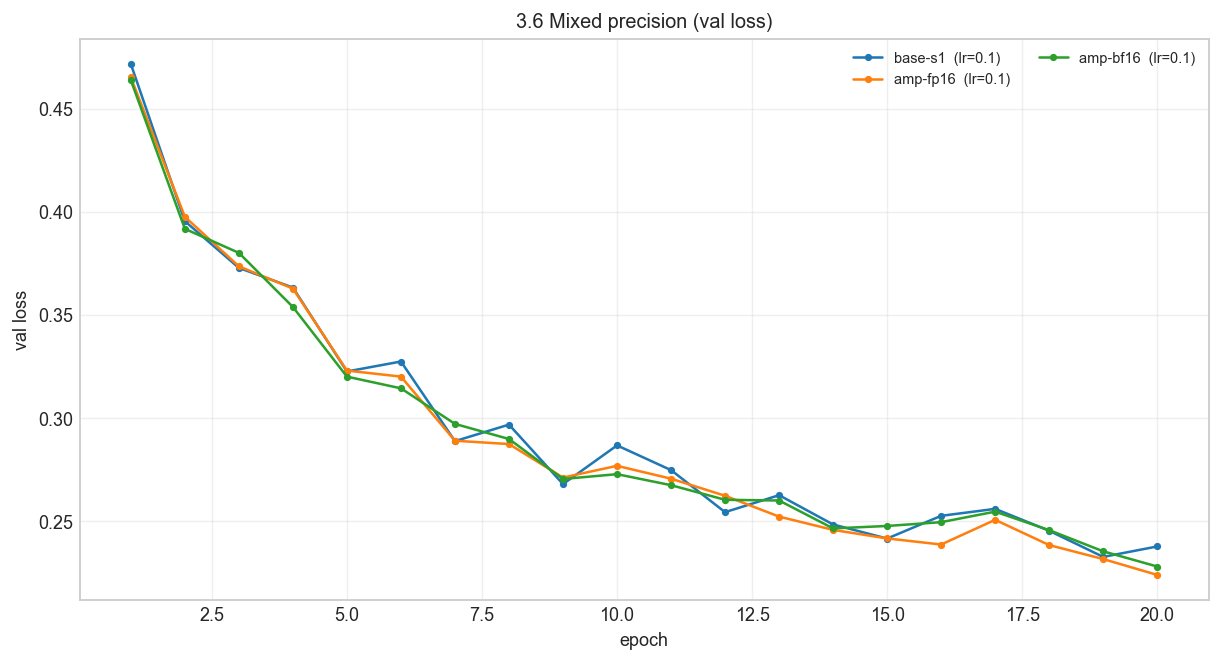

In [16]:
# ---- 3.6 FP32 vs FP16 vs BF16 ----
bf16_hw = bool(device == "cuda" and torch.cuda.is_bf16_supported())
run_exp({**BASE, "lr": BASE_LR, "exp_id": "amp-fp16", "group": "amp", "precision": "fp16",
         "clip_norm": CLIP_C,
         "description": "FP16 autocast + GradScaler (fp32: 0 clip)",
         "notes": "Dự đoán: không nhanh hơn FP32 vì mạng nhỏ; chất lượng gần như không đổi."})
run_exp({**BASE, "lr": BASE_LR, "exp_id": "amp-bf16", "group": "amp", "precision": "bf16",
         "clip_norm": CLIP_C,
         "description": "BF16 autocast (không GradScaler)",
         "notes": ("GPU có phần cứng BF16." if bf16_hw else
                   "GPU KHÔNG có phần cứng BF16 (ví dụ T4/P100) -> chạy mô phỏng phần mềm, "
                   "thường chậm hơn cả FP32; vẫn ghi kết quả để minh bạch.")})

amp_df = brief(["base-s1", "amp-fp16", "amp-bf16"])
display(amp_df)
print("\nThời gian / bộ nhớ / độ chính xác so với FP32:")
base_t = RESULTS["base-s1"]["summary"]
for e in ("amp-fp16", "amp-bf16"):
    s = RESULTS[e]["summary"]
    print(f"  {e:10s} {s['time_per_epoch_s']:6.2f} s/epoch ({s['time_per_epoch_s']/base_t['time_per_epoch_s']:5.2f}× fp32)"
          f" | peak {s['peak_mem_MB']:6.1f} MB ({s['peak_mem_MB']/max(base_t['peak_mem_MB'],1e-9):5.2f}×)"
          f" | val macro-F1 {s['val_macro_f1']:.4f} (Δ = {s['val_macro_f1']-base_t['val_macro_f1']:+.4f})")
plot_compare([RESULTS[e] for e in ("base-s1", "amp-fp16", "amp-bf16")], "val_loss",
             f"{FIGS_DIR}/compare_amp.png", "3.6 Mixed precision (val loss)")
show_fig("compare_amp")

### 3.7 Khởi tạo tham số

| init | công thức | PyTorch |
|---|---|---|
| `zeros` | `W = 0` | `nn.init.zeros_` |
| `normal` | `W ~ N(0, 0.01²)` | `nn.init.normal_` |
| `xavier` | `Var[W] = 2/(n_in+n_out)` | `nn.init.xavier_normal_` |
| `he` | `Var[W] = 2/n_in` | `nn.init.kaiming_normal_(w, nonlinearity="relu")` |
| `default` | mặc định `nn.Linear` (uniform ±1/√n_in, **không phải He**) | không làm gì |

**Dự đoán trước khi chạy.**

- `zeros`: mọi nơ-ron cùng lớp nhận **cùng một** gradient → W giữ nguyên tính đối xứng → mạng
  không học được (tương đương một nơ-ron duy nhất). Thêm nữa ReLU(0) = 0 nên gradient qua tầng ẩn
  bị chặn hoàn toàn. Dự đoán: val macro-F1 ≈ 0.09 (mức đoán đa số).
- `normal (std=0.01)`: tín hiệu bị thu nhỏ qua mỗi tầng → độ lệch chuẩn kích hoạt giảm dần theo tầng,
  học chậm nhưng vẫn học được.
- `xavier` giữ phương sai qua tầng nhưng tính cả nhiều chiều (`2/(n_in+n_out)`) nên **giảm** phương sai
  kích hoạt; `he` chỉ dùng `n_in` (`2/n_in`) nên **bù đúng** phần tắt một nửa của ReLU → phương sai
  kích hoạt giữ gần như không đổi qua các tầng. Với ReLU, He đúng hơn Xavier.
- `default` có phương sai `1/(3·n_in)` — nhỏ hơn He một nửa → tín hiệu yếu dần.

  [init-zeros] ep   1/20  train_loss 1.2103  val_loss 1.2052  val_acc 0.4876  val_f1 0.0936  gbar 4.138e-02  1.6s


  [init-zeros] ep   2/20  train_loss 1.2102  val_loss 1.2052  val_acc 0.4876  val_f1 0.0936  gbar 3.334e-02  1.6s


  [init-zeros] ep   3/20  train_loss 1.2107  val_loss 1.2055  val_acc 0.4876  val_f1 0.0936  gbar 3.269e-02  1.8s


  [init-zeros] ep   4/20  train_loss 1.2106  val_loss 1.2054  val_acc 0.4876  val_f1 0.0936  gbar 3.341e-02  1.8s


  [init-zeros] ep   5/20  train_loss 1.2103  val_loss 1.2053  val_acc 0.4876  val_f1 0.0936  gbar 3.399e-02  1.7s


...

  [init-default] ep  20/20  train_loss 0.2128  val_loss 0.2329  val_acc 0.9068  val_f1 0.8578  gbar 5.720e-01  1.2s


Độ lệch chuẩn kích hoạt ở bước 0 (một lô val) và kết quả sau 20 epoch:


,exp_id,init,step0_loss,std_tầng1,std_tầng2,std_logits,val_macro_f1,val_acc,s_per_epoch
0,init-zeros,zeros,1.9459,0.0000,0.0000,0.0000,0.0936,0.4876,1.59
1,init-normal,normal,1.9460,0.0211,0.0025,0.0002,0.8609,0.9070,1.57
2,init-xavier,xavier,2.0222,0.1696,0.1448,0.1620,0.8561,0.9087,1.58
3,init-default,default,1.9830,0.1693,0.0674,0.0616,0.8578,0.9068,1.24


Baseline (he): {'std_tầng1': 0.390777051448822, 'std_tầng2': 0.39384153485298157}


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,init-normal,0.8609,0.0028,Không,0.9070,0.2321,20,0.0194,1.57,180.0,N
1,init-default,0.8578,-0.0003,Không,0.9068,0.2329,20,0.0200,1.24,180.0,N
2,base-s1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.50,174.0,N
3,init-xavier,0.8561,-0.0020,Không,0.9087,0.2292,20,0.0215,1.58,180.0,N
4,init-zeros,0.0936,-0.7645,Có,0.4876,1.2052,2,-0.0054,1.59,180.0,N


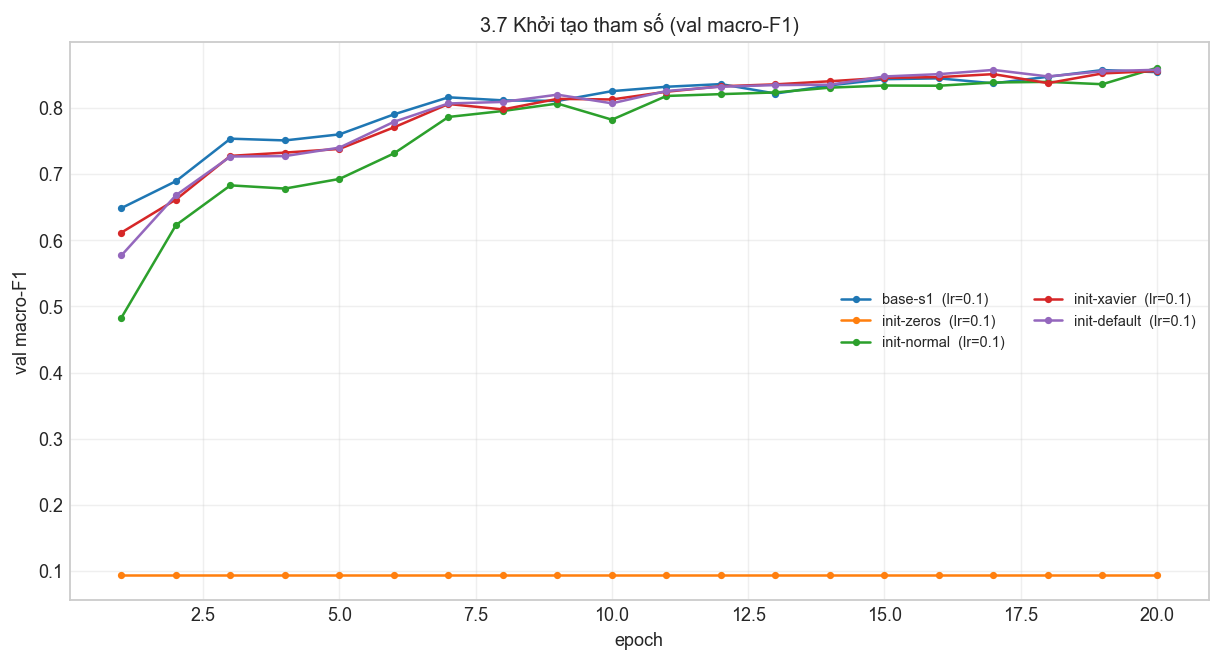

In [17]:
# ---- 3.7 Khởi tạo: zeros / normal / xavier / default (baseline là He) ----
INITS = [
    ("init-zeros",  "zeros",  "W = 0 — mất tính đối xứng, ReLU(0) chặn gradient"),
    ("init-normal", "normal", "W ~ N(0, 0.01^2) — tín hiệu nhỏ, học chậm"),
    ("init-xavier", "xavier", "xavier_normal_: Var = 2/(n_in+n_out)"),
    ("init-default", "default", "mặc định nn.Linear: uniform, Var = 1/(3 n_in) — KHÔNG phải He"),
]
stat_rows = []
for eid, init, desc in INITS:
    run_exp({**BASE, "lr": BASE_LR, "exp_id": eid, "group": "init", "init": init,
             "description": f"Khởi tạo {init}", "notes": desc})
    stds = activation_stats(MLP((256, 128), init=init).to(device), data["X_val"][:20_000])
    s = RESULTS[eid]["summary"]
    stat_rows.append(dict(exp_id=eid, init=init,
                          step0_loss=round(s["step0_loss"], 4),
                          **{f"std_tầng{i+1}": round(v, 4) for i, v in enumerate(stds[:2])},
                          std_logits=round(stds[2], 4),
                          val_macro_f1=round(s["val_macro_f1"], 4),
                          val_acc=round(s["val_acc"], 4),
                          s_per_epoch=round(s["time_per_epoch_s"], 2)))
print("Độ lệch chuẩn kích hoạt ở bước 0 (một lô val) và kết quả sau 20 epoch:")
display(pd.DataFrame(stat_rows))
print("Baseline (he): " + str({f"std_tầng{i+1}": v for i, v in
      enumerate(activation_stats(MLP((256, 128), init="he").to(device), data["X_val"][:20_000])[:2])}))
display(brief(["base-s1"] + [e for e, _, _ in INITS]))
plot_compare([RESULTS["base-s1"]] + [RESULTS[e] for e, _, _ in INITS],
             "val_macro_f1", f"{FIGS_DIR}/compare_init.png", "3.7 Khởi tạo tham số (val macro-F1)")
show_fig("compare_init")

**Đối chiếu 3.7.** Với `zeros`, gradient của các nơ-ron trong cùng một tầng có **bằng nhau không**?
(hãy in ra để trả lời bằng số liệu). Mạng 3 tầng có đủ sâu để thấy rõ khác biệt phương sai kích
hoạt giữa `he` và `xavier` không, hay phải dùng mạng sâu hơn nhiều mới thấy?

---
## 3.8 Cấu hình cuối cùng (chọn **bằng val**)

Ghép các lựa chọn đã được val ủng hộ: bộ tối ưu + `lr` tốt nhất (3.2), `dropout` (3.4), và số epoch
lớn hơn (3.3). **Không** dùng tập eval ở mọi bước của phần này.

Cấu hình cuối cùng (ghép từ val):
{'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'dropout': 0.0, 'batch': 512, 'epochs': 40, 'hidden': (256, 128), 'init': 'he'}
Các yếu tố này đổi so với baseline: optimizer+lr (3.2), dropout (3.4), số epoch (3.3).


  [final-s1] ep   1/40  train_loss 0.4349  val_loss 0.4390  val_acc 0.8123  val_f1 0.6621  gbar 6.384e-01  1.4s


  [final-s1] ep   2/40  train_loss 0.3647  val_loss 0.3719  val_acc 0.8424  val_f1 0.7259  gbar 6.499e-01  1.3s


  [final-s1] ep   3/40  train_loss 0.3391  val_loss 0.3456  val_acc 0.8566  val_f1 0.7739  gbar 6.847e-01  1.4s


  [final-s1] ep   4/40  train_loss 0.3167  val_loss 0.3244  val_acc 0.8651  val_f1 0.7950  gbar 6.784e-01  1.3s


...

  [final-s3] ep  38/40  train_loss 0.1474  val_loss 0.1867  val_acc 0.9284  val_f1 0.8938  gbar 6.807e-01  1.6s


  [final-s3] ep  39/40  train_loss 0.1558  val_loss 0.1918  val_acc 0.9269  val_f1 0.8879  gbar 6.565e-01  1.6s


  [final-s3] ep  40/40  train_loss 0.1506  val_loss 0.1854  val_acc 0.9287  val_f1 0.8965  gbar 6.671e-01  1.7s


,exp_id,val_macro_f1,delta_vs_base,vượt_2σ,val_acc,best_val_loss,best_epoch,gap_val_minus_train,s_per_epoch,peak_MB,diverged
0,final-s3,0.8965,0.0384,Có,0.9287,0.1854,40,0.0348,1.66,181.0,N
1,final-s2,0.8932,0.0351,Có,0.9312,0.1809,39,0.0383,1.68,181.0,N
2,final-s1,0.8901,0.0320,Có,0.9273,0.1883,38,0.0338,1.38,181.0,N
3,base-s1,0.8575,-0.0006,Không,0.9071,0.2327,19,0.0217,1.50,174.0,N



Cấu hình cuối cùng qua 3 seed:
  val macro-F1 = 0.8933 ± 0.0032 (σ)
  val accuracy = 0.9291 ± 0.0020 (σ)
  baseline      = 0.8581 ± 0.0019 (σ)
  Δ = +0.0352  |  2σ_baseline = 0.0038  ->  VƯỢT nhiễu


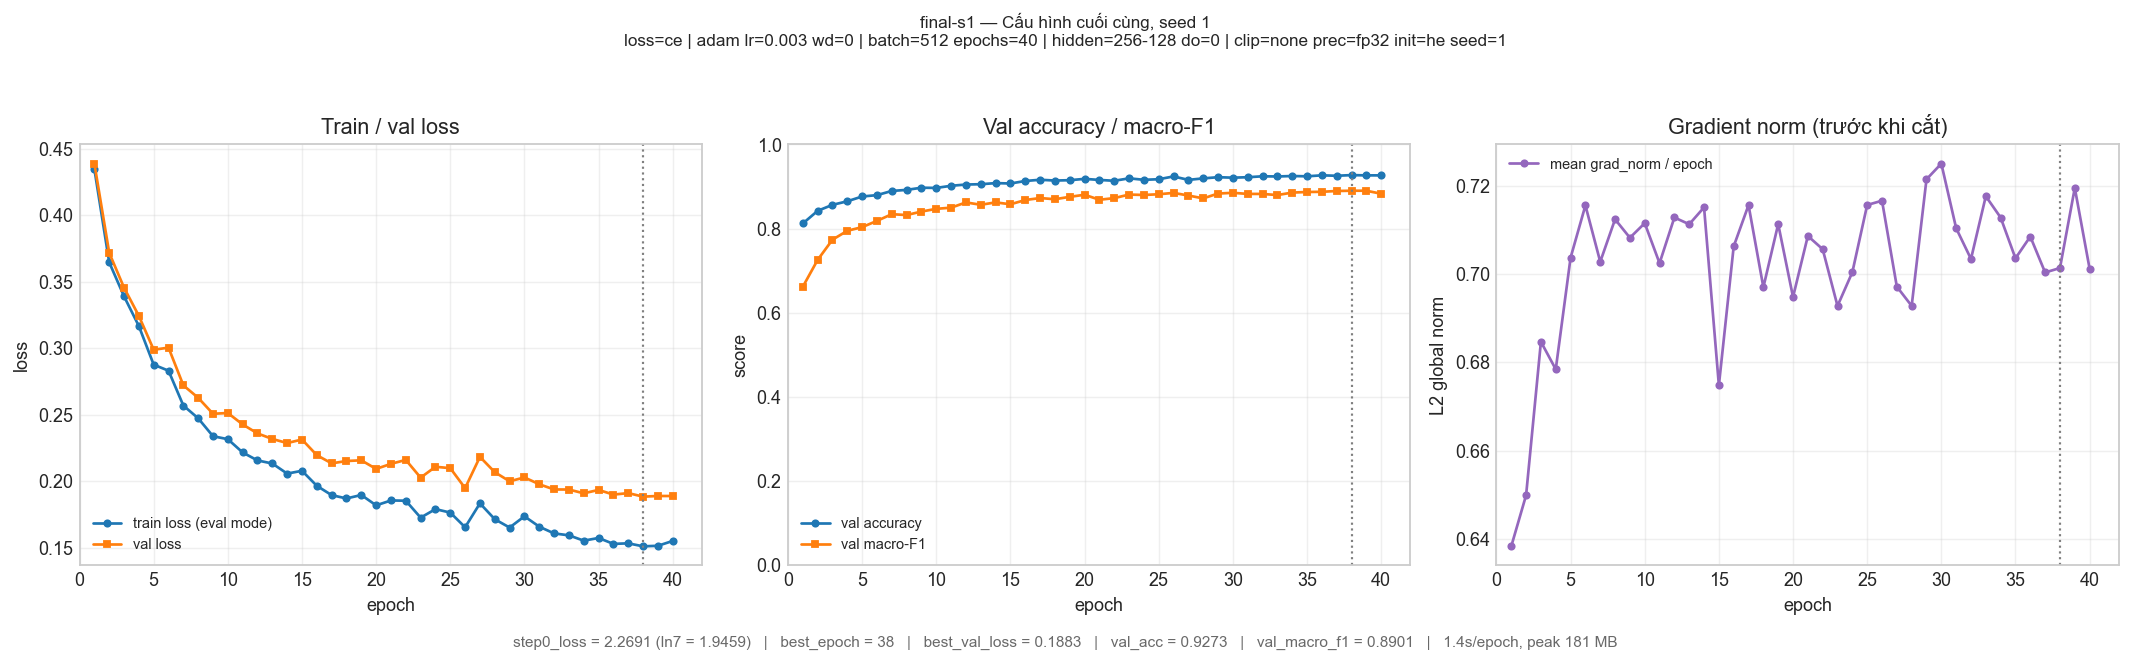

In [18]:
# ---- Cấu hình cuối cùng: chỉ ghép những gì đã có bằng chứng từ val ----
Q_DROP = 0.1 if RESULTS["drop-0.1"]["summary"]["val_macro_f1"] >= RESULTS["base-s1"]["summary"]["val_macro_f1"] else 0.0
FINAL_BASE = {**BASE,
              "optimizer": BEST_OPT_CFG["optimizer"],
              "lr": BEST_OPT_CFG["lr"],
              "weight_decay": BEST_OPT_CFG["weight_decay"],
              "momentum": BEST_OPT_CFG["momentum"],
              "dropout": Q_DROP,
              "epochs": EPOCHS_FINAL}
print("Cấu hình cuối cùng (ghép từ val):")
print({k: FINAL_BASE[k] for k in ("optimizer", "lr", "weight_decay", "dropout", "batch", "epochs", "hidden", "init")})
print("Các yếu tố này đổi so với baseline: optimizer+lr (3.2), dropout (3.4), số epoch (3.3).")

FINAL_SEEDS = [1, 2, 3]
for s in FINAL_SEEDS:
    run_exp({**FINAL_BASE, "exp_id": f"final-s{s}", "group": "final", "seed": s,
             "description": f"Cấu hình cuối cùng, seed {s}",
             "notes": "Ghép các lựa chọn có bằng chứng từ val; chạy 3 seed để báo cáo trung bình ± σ."})
display(brief(["base-s1"] + [f"final-s{s}" for s in FINAL_SEEDS]))

f_stat = noise_stats([to_row(RESULTS[e]) for e in [f"final-s{s}" for s in FINAL_SEEDS]],
                     [f"final-s{s}" for s in FINAL_SEEDS])
print("\nCấu hình cuối cùng qua 3 seed:")
print(f"  val macro-F1 = {f_stat['val_macro_f1']['mean']:.4f} ± {f_stat['val_macro_f1']['std']:.4f} (σ)")
print(f"  val accuracy = {f_stat['val_acc']['mean']:.4f} ± {f_stat['val_acc']['std']:.4f} (σ)")
b_stat = NOISE
print(f"  baseline      = {b_stat['val_macro_f1']['mean']:.4f} ± {b_stat['val_macro_f1']['std']:.4f} (σ)")
delta = f_stat['val_macro_f1']['mean'] - b_stat['val_macro_f1']['mean']
print(f"  Δ = {delta:+.4f}  |  2σ_baseline = {b_stat['val_macro_f1']['two_sigma']:.4f}  ->  "
      f"{'VƯỢT nhiễu' if abs(delta) > b_stat['val_macro_f1']['two_sigma'] else 'CHƯA vượt nhiễu'}")
show_fig("final-s1")

---
## Part 4 — Đánh giá cuối trên tập eval, bảng và phân tích lỗi

Cấu hình đã chọn **bằng val** ở trên. Bây giờ mới dùng tập `eval` (116 203 mẫu), và **chỉ dùng
đúng một lần cho mỗi cấu hình**: baseline và cấu hình cuối cùng.

In [19]:
# ---- Dự đoán trên toàn bộ eval, cho baseline và cấu hình cuối cùng ----
# (chạy lại từ đầu vì best_state không lưu trong results/*.json)
res_base   = run_experiment({**BASE,   "lr": BASE_LR, "seed": 1}, data)
res_final  = run_experiment({**FINAL_BASE, "exp_id": "final-s1", "seed": 1}, data)
RESULTS["base-s1"], RESULTS["final-s1"] = res_base, res_final
save_result(res_base, RES_DIR);  save_result(res_final, RES_DIR)
plot_run(res_base,  f"{FIGS_DIR}/base-s1.png")
plot_run(res_final, f"{FIGS_DIR}/final-s1.png")

_ = final_eval({**BASE, "lr": BASE_LR, "exp_id": "base-s1"}, res_base,  data,
                f"{OUT_DIR}/predictions_eval_baseline.csv")
_ = final_eval({**FINAL_BASE, "exp_id": "final-s1"},               res_final, data,
                f"{OUT_DIR}/predictions_eval.csv")

  [base-s1] ep   1/20  train_loss 0.4677  val_loss 0.4718  val_acc 0.7955  val_f1 0.6487  gbar 5.246e-01  1.5s


  [base-s1] ep   2/20  train_loss 0.3898  val_loss 0.3956  val_acc 0.8363  val_f1 0.6894  gbar 5.680e-01  1.5s


  [base-s1] ep   3/20  train_loss 0.3686  val_loss 0.3729  val_acc 0.8455  val_f1 0.7537  gbar 5.833e-01  1.7s


  [base-s1] ep   4/20  train_loss 0.3571  val_loss 0.3634  val_acc 0.8490  val_f1 0.7511  gbar 5.771e-01  1.6s


  [base-s1] ep   5/20  train_loss 0.3134  val_loss 0.3227  val_acc 0.8647  val_f1 0.7602  gbar 5.854e-01  1.4s


...

  [final-s1] ep  37/40  train_loss 0.1532  val_loss 0.1910  val_acc 0.9257  val_f1 0.8895  gbar 7.003e-01  1.6s


  [final-s1] ep  38/40  train_loss 0.1509  val_loss 0.1883  val_acc 0.9273  val_f1 0.8901  gbar 7.013e-01  1.6s


  [final-s1] ep  39/40  train_loss 0.1513  val_loss 0.1888  val_acc 0.9266  val_f1 0.8902  gbar 7.194e-01  1.6s


  [final-s1] ep  40/40  train_loss 0.1550  val_loss 0.1888  val_acc 0.9266  val_f1 0.8830  gbar 7.012e-01  1.5s


đã ghi C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork\submission_2A202602590/predictions_eval_baseline.csv  (116203 dòng)
đã dự đoán eval bằng base-s1 (best_epoch = 19, val macro-F1 = 0.8575)
đã ghi C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork\submission_2A202602590/predictions_eval.csv  (116203 dòng)
đã dự đoán eval bằng final-s1 (best_epoch = 38, val macro-F1 = 0.8901)


In [20]:
# ---- Chấm bằng đúng scripts/evaluate.py ----
for name, out in (("predictions_eval_baseline.csv", "eval_result_baseline.json"),
                  ("predictions_eval.csv", "eval_result.json")):
    subprocess.run([sys.executable, os.path.join(REPO_ROOT, "scripts", "evaluate.py"),
                    "--pred", os.path.join(OUT_DIR, name),
                    "--data", os.path.join(REPO_ROOT, "data", "covtype.csv.gz"),
                    "--meta", os.path.join(REPO_ROOT, "data", "split_metadata.csv"),
                    "--out", os.path.join(OUT_DIR, out)], cwd=REPO_ROOT, check=True, env=SUBENV)

EVAL_BASE  = json.load(open(f"{OUT_DIR}/eval_result_baseline.json", encoding="utf-8"))
EVAL_FINAL = json.load(open(f"{OUT_DIR}/eval_result.json", encoding="utf-8"))
print("\n" + "=" * 78)
print(f"{'cấu hình':<26s} {'val macro-F1':>13s} {'EVAL macro-F1':>14s} {'EVAL accuracy':>14s}")
print("-" * 78)
print(f"{'baseline (base-s1)':<26s} {res_base['summary']['val_macro_f1']:>13.4f} "
      f"{EVAL_BASE['macro_f1']:>14.4f} {EVAL_BASE['accuracy']:>14.4f}")
print(f"{'cấu hình cuối cùng':<26s} {res_final['summary']['val_macro_f1']:>13.4f} "
      f"{EVAL_FINAL['macro_f1']:>14.4f} {EVAL_FINAL['accuracy']:>14.4f}")
print(f"{'cải thiện (eval)':<26s} {'':>13s} "
      f"{EVAL_FINAL['macro_f1'] - EVAL_BASE['macro_f1']:>+14.4f}")
print(f"{'chênh lệch val - eval (final)':<26s} "
      f"{res_final['summary']['val_macro_f1'] - EVAL_FINAL['macro_f1']:>+13.4f}")
print("=" * 78)
print("nếu val và eval lệch nhau nhiều, nguyên nhân có thể là: chọn best epoch trên val bị overfit "
      "slight lên val, hoặc val nhỏ hơn/thống kê khác eval.")


cấu hình                    val macro-F1  EVAL macro-F1  EVAL accuracy
------------------------------------------------------------------------------
baseline (base-s1)                0.8575         0.8564         0.9058
cấu hình cuối cùng                0.8901         0.8934         0.9265
cải thiện (eval)                                +0.0370
chênh lệch val - eval (final)       -0.0032
nếu val và eval lệch nhau nhiều, nguyên nhân có thể là: chọn best epoch trên val bị overfit slight lên val, hoặc val nhỏ hơn/thống kê khác eval.


,cls,support,precision,recall,f1
0,0,42368,0.9071,0.9390,0.9228
1,1,56661,0.9464,0.9254,0.9358
2,2,7151,0.9233,0.9358,0.9295
3,3,549,0.8952,0.7778,0.8324
4,4,1899,0.8611,0.7930,0.8257
5,5,3473,0.8793,0.8560,0.8675
6,6,4102,0.9409,0.9388,0.9398


ma trận nhầm lẫn trên eval (hàng = nhãn thật, cột = dự đoán):


,0,1,2,3,4,5,6
0 Spruce/Fir,39782,2337,4,0,34,3,208
1 Lodgepole Pine,3796,52433,114,0,181,103,34
2 Ponderosa Pine,0,160,6692,33,21,245,0
3 Cottonwood/Willow,0,1,76,427,0,45,0
4 Aspen,47,320,14,0,1506,12,0
5 Douglas-fir,10,119,348,17,6,2973,0
6 Krummholz,219,31,0,0,1,0,3851


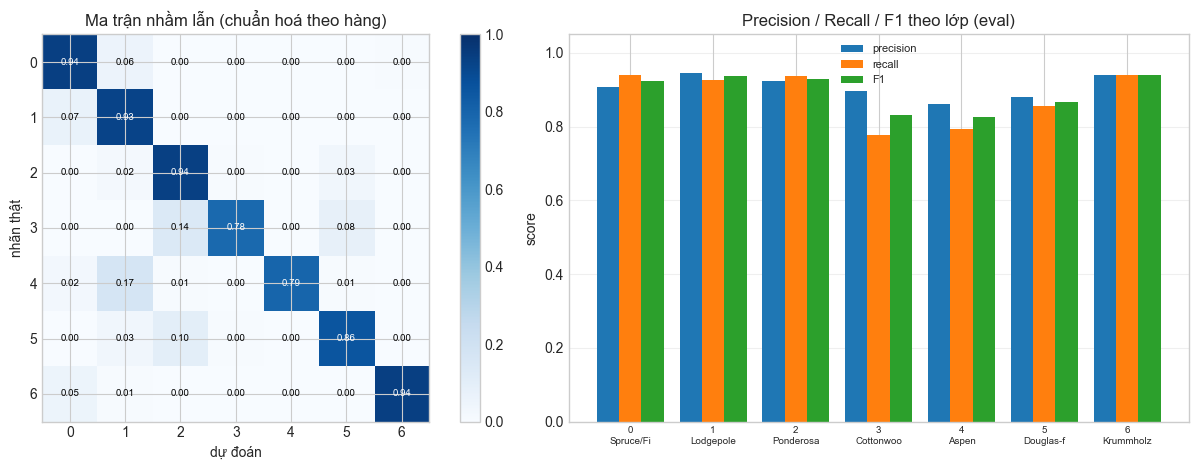


Lớp khó nhất: lớp 4 (Aspen) — F1 = 0.8257, support = 1899
bị nhầm nhiều nhất với: lớp 1 (Lodgepole Pine): 320 mẫu, lớp 0 (Spruce/Fir): 47 mẫu, lớp 2 (Ponderosa Pine): 14 mẫu
recall thấp nhất: 3 | precision thấp nhất: 4


In [21]:
# ---- 4b: phân tích lỗi theo lớp trên eval (từ eval_result.json) ----
pc = pd.DataFrame(EVAL_FINAL["per_class"])
pc.columns = ["cls", "support", "precision", "recall", "f1"]
display(pc.round(4))
cm = np.array(EVAL_FINAL["confusion_matrix"])
NAME = {0: "Spruce/Fir", 1: "Lodgepole Pine", 2: "Ponderosa Pine", 3: "Cottonwood/Willow",
        4: "Aspen", 5: "Douglas-fir", 6: "Krummholz"}
print("ma trận nhầm lẫn trên eval (hàng = nhãn thật, cột = dự đoán):")
display(pd.DataFrame(cm, index=[f"{i} {NAME[i]}" for i in range(7)],
                     columns=[str(i) for i in range(7)]))

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)     # chuẩn hoá theo hàng = recall
im = ax[0].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax[0].set_xticks(range(7)); ax[0].set_yticks(range(7))
ax[0].set_xticklabels(range(7)); ax[0].set_yticklabels(range(7))
ax[0].set_xlabel("dự đoán"); ax[0].set_ylabel("nhãn thật"); ax[0].set_title("Ma trận nhầm lẫn (chuẩn hoá theo hàng)")
for i in range(7):
    for j in range(7):
        ax[0].text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=7,
                   color="white" if cmn[i, j] > 0.5 else "black")
fig.colorbar(im, ax=ax[0], fraction=0.046)
x = np.arange(7); w = 0.27
ax[1].bar(x - w, pc["precision"], w, label="precision")
ax[1].bar(x,     pc["recall"],    w, label="recall")
ax[1].bar(x + w, pc["f1"],        w, label="F1")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"{i}\n{NAME[i][:9]}" for i in range(7)], fontsize=7)
ax[1].set_ylim(0, 1.05); ax[1].set_ylabel("score"); ax[1].set_title("Precision / Recall / F1 theo lớp (eval)")
ax[1].legend(fontsize=8); ax[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(f"{FIGS_DIR}/error_analysis_eval.png", dpi=130, bbox_inches="tight")
plt.show()

worst = int(pc.loc[pc["f1"].idxmin(), "cls"])
conf = [(j, int(cm[worst, j])) for j in range(7) if j != worst]
conf.sort(key=lambda t: -t[1])
print(f"\nLớp khó nhất: lớp {worst} ({NAME[worst]}) — F1 = {pc.loc[pc['cls']==worst,'f1'].iat[0]:.4f}, "
      f"support = {int(pc.loc[pc['cls']==worst,'support'].iat[0])}")
print("bị nhầm nhiều nhất với:", ", ".join(f"lớp {j} ({NAME[j]}): {n} mẫu" for j, n in conf[:3]))
print("recall thấp nhất:", int(pc.loc[pc['recall'].idxmin(),'cls']),
      "| precision thấp nhất:", int(pc.loc[pc['precision'].idxmin(),'cls']))

**Phân tích lỗi (viết bằng lời của bạn):** lớp khó nhất là lớp ... vì ...
(số mẫu ít nhất thì recall dễ thấp; hai lớp có đặc trưng gần nhau thì dễ nhầm hai chiều —
nhìn số ở hàng `worst` và cột `worst` của ma trận). Một cách cải thiện sẽ thử: ...

In [22]:
# ---- 4a: điền experiments.xlsx ----
NOTES = {e: RESULTS[e]["cfg"].get("notes", "") for e in RESULTS}

# Sắp xếp theo thứ tự nhóm để bảng dễ đọc
GROUP_ORDER = ["baseline", "loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init", "final", "other"]
def _key(e):
    g = RESULTS[e]["cfg"].get("group", "other")
    return (GROUP_ORDER.index(g) if g in GROUP_ORDER else 99, e)

SEED_IDS = [f"base-s{s}" for s in BASE_SEEDS]
FINAL_IDS = [f"final-s{s}" for s in FINAL_SEEDS]
EVAL_FOR = {"base-s1": EVAL_BASE, "final-s1": EVAL_FINAL}   # eval CHỈ cho baseline và cấu hình cuối

rows = []
for e in sorted(RESULTS, key=_key):
    rows.append(to_row(RESULTS[e], eval_scores=EVAL_FOR.get(e), notes=NOTES.get(e, "")))

def _f1(e):
    return RESULTS[e]["summary"]["val_macro_f1"] if e in RESULTS else float("nan")

SUMMARY_NOTES = {
    "baseline": f"{BASE['optimizer']} lr={BASE_LR:g}, {EPOCHS} ep. TB val macro-F1 = "
                f"{NOISE['val_macro_f1']['mean']:.4f} ± {NOISE['val_macro_f1']['std']:.4f} "
                f"(2σ = {NOISE['val_macro_f1']['two_sigma']:.4f}, 3 seed). Mốc đoán đa số = "
                f"{data['majority_acc_val']:.4f}.",
    "loss": f"MSE cho val macro-F1 = {_f1('loss-mse'):.4f} so với CE = {_f1('base-s1'):.4f}; "
            f"loss khác thang đo nên chỉ so bằng macro-F1.",
    "optimizer": f"Bộ tối ưu tốt nhất theo val: {BEST_OPT_CFG['optimizer']} lr={BEST_OPT_CFG['lr']:g} "
                 f"(val macro-F1 {RESULTS[BEST_OPT_EID]['summary']['val_macro_f1']:.4f}). "
                 "Mỗi bộ thử 3 lr; SGD nhạy lr nhất.",
    "hparam": "Batch, kiến trúc, weight decay, cosine, số epoch — xem notes từng dòng.",
    "dropout": f"q chọn cho cấu hình cuối: {Q_DROP:g}.",
    "clipping": f"c = {CLIP_C:g}; thí nghiệm phản chứng ở lr = {HIGH_LR:g}.",
    "amp": "FP16/BF16 không nhanh hơn FP32 trên mạng nhỏ này; xem time/epoch và peak mem.",
    "init": "zeros hỏng vì mất đối xứng; he giữ phương sai kích hoạt qua tầng ReLU.",
    "final": f"Ghép từ val; eval macro-F1 = {EVAL_FINAL['macro_f1']:.4f} "
             f"(cải thiện {EVAL_FINAL['macro_f1'] - EVAL_BASE['macro_f1']:+.4f} so với baseline).",
}
write_xlsx(rows, os.path.join(REPO_ROOT, "templates", "experiment_table_template.xlsx"),
           f"{OUT_DIR}/experiments.xlsx", seed_ids=SEED_IDS, summary_notes=SUMMARY_NOTES)

# ---- kiểm tra: mỗi dòng bảng phải có đúng một ảnh figures/<exp_id>.png ----
png = {f[:-4] for f in os.listdir(FIGS_DIR) if f.endswith(".png")}
missing = sorted(e for e in RESULTS if e not in png)
extra = sorted(png - set(RESULTS))
print(f"\nSố dòng thí nghiệm trong bảng : {len(rows)}")
print(f"Số ảnh figures/<exp_id>.png    : {len(png & set(RESULTS))}")
print(f"Thiếu ảnh                     : {missing or 'không có'}")
print(f"Ảnh khác (không phải exp_id)  : {extra or 'không có'}")
assert not missing, f"thiếu ảnh cho: {missing}"

đã ghi C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork\submission_2A202602590/experiments.xlsx (39 dòng thí nghiệm)
Mở file bằng Excel/LibreOffice để các cột công thức (2σ, beyond_noise) tính lại.

Số dòng thí nghiệm trong bảng : 39
Số ảnh figures/<exp_id>.png    : 39
Thiếu ảnh                     : không có
Ảnh khác (không phải exp_id)  : ['compare_amp', 'compare_clipping', 'compare_dropout', 'compare_hparam', 'compare_init', 'compare_loss', 'compare_opt_adam', 'compare_opt_adamw', 'compare_opt_sgd', 'compare_opt_sgd_momentum', 'compare_optimizer', 'compare_seed', 'error_analysis_eval']


In [23]:
# ---- BẢNG SỐ LIỆU CHO BÁO CÁO (chép từ đây) ----
print("=" * 78); print("BẢNG SỐ LIỆU CHO REPORT.md"); print("=" * 78)
print(f"[2] loss bước 0 (He)          = {res_base['summary']['step0_loss']:.4f}   (ln 7 = {LN_C:.4f})")
print(f"[2] quá khớp 20 mẫu, loss cuối = {losses[-1]:.2e}")
print(f"[2] baseline val macro-F1     = {NOISE['val_macro_f1']['mean']:.4f} ± {NOISE['val_macro_f1']['std']:.4f} (σ)")
print(f"[2] baseline val accuracy     = {NOISE['val_acc']['mean']:.4f} ± {NOISE['val_acc']['std']:.4f} (σ)")
print(f"[2] NGƯỠNG NHIỄU 2σ           = {NOISE['val_macro_f1']['two_sigma']:.4f}  (val macro-F1)")
print(f"[2] mốc 'đoán lớp đa số'      = {data['majority_acc_val']:.4f} accuracy")
print(f"[4] eval baseline   : acc {EVAL_BASE['accuracy']:.4f}  macro-F1 {EVAL_BASE['macro_f1']:.4f}")
print(f"[4] eval cấu hình cuối: acc {EVAL_FINAL['accuracy']:.4f}  macro-F1 {EVAL_FINAL['macro_f1']:.4f}")
print(f"[4] val vs eval (cấu hình cuối): {res_final['summary']['val_macro_f1']:.4f} vs {EVAL_FINAL['macro_f1']:.4f}")
print("\nBảng đầy đủ (mỗi thí nghiệm một dòng):")
display(pd.DataFrame(rows)[["exp_id", "group", "val_macro_f1", "val_acc", "best_val_loss",
                            "best_epoch", "time_per_epoch_s", "peak_mem_MB", "diverged",
                            "eval_macro_f1", "eval_acc"]])
print("\nCác file đã sinh trong", OUT_DIR)
for d in ("figures", "results"):
    fs = sorted(os.listdir(f"{OUT_DIR}/{d}"))
    print(f"  {d}/ ({len(fs)} file)")
print("  " + ", ".join(x for x in ("experiments.xlsx", "predictions_eval.csv", "eval_result.json") if os.path.isfile(f"{OUT_DIR}/{x}")))

BẢNG SỐ LIỆU CHO REPORT.md
[2] loss bước 0 (He)          = 2.2691   (ln 7 = 1.9459)
[2] quá khớp 20 mẫu, loss cuối = 5.23e-05
[2] baseline val macro-F1     = 0.8581 ± 0.0019 (σ)
[2] baseline val accuracy     = 0.9102 ± 0.0030 (σ)
[2] NGƯỠNG NHIỄU 2σ           = 0.0038  (val macro-F1)
[2] mốc 'đoán lớp đa số'      = 0.4876 accuracy
[4] eval baseline   : acc 0.9058  macro-F1 0.8564
[4] eval cấu hình cuối: acc 0.9265  macro-F1 0.8934
[4] val vs eval (cấu hình cuối): 0.8901 vs 0.8934

Bảng đầy đủ (mỗi thí nghiệm một dòng):


,exp_id,group,val_macro_f1,val_acc,best_val_loss,best_epoch,time_per_epoch_s,peak_mem_MB,diverged,eval_macro_f1,eval_acc
0,base-s1,baseline,0.857493,0.907059,0.232698,19,1.44,180.9,N,0.856395,0.905846
1,base-s2,baseline,0.856555,0.910759,0.223983,20,1.64,174.0,N,NaN,NaN
2,base-s3,baseline,0.860253,0.912921,0.223588,20,1.81,174.2,N,NaN,NaN
3,final-s1,baseline,0.890137,0.927261,0.188319,38,1.57,181.3,N,0.893351,0.926517
4,loss-mse,loss,0.733432,0.869151,0.029812,18,1.71,174.4,N,NaN,NaN
5,opt-adam-lr0.0003,optimizer,0.795432,0.873669,0.311052,20,2.15,175.3,N,NaN,NaN
6,opt-adam-lr0.001,optimizer,0.850376,0.902627,0.241220,20,1.53,175.5,N,NaN,NaN
7,opt-adam-lr0.003,optimizer,0.880572,0.918311,0.209185,20,1.56,175.7,N,NaN,NaN
8,opt-adamw-lr0.0003,optimizer,0.795920,0.874217,0.312560,20,1.63,175.9,N,NaN,NaN
9,opt-adamw-lr0.001,optimizer,0.847153,0.901820,0.245964,20,1.78,176.1,N,NaN,NaN



Các file đã sinh trong C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork\submission_2A202602590
  figures/ (52 file)
  results/ (39 file)
  experiments.xlsx, predictions_eval.csv, eval_result.json


---
## 5. Đóng gói thư mục nộp

Tạo `submission_<MSSV>/` đúng cấu trúc README mục 6.1, rồi nén lại để nộp.
Đặt tên thư mục bằng cách sửa `LAB_SUBMISSION` hoặc dòng `SUBMISSION_NAME` bên dưới.

In [24]:
import shutil

_def_name = os.environ.get("LAB_SUBMISSION")
if not _def_name:                       # nếu OUT_DIR đã là thư mục nộp thì dùng luôn tên đó
    _b = os.path.basename(os.path.abspath(OUT_DIR))
    _def_name = _b if _b.startswith("submission") else "submission"
SUBMISSION_NAME = _def_name
PKG = os.path.join(REPO_ROOT, SUBMISSION_NAME)

def _same(a, b):
    return os.path.abspath(a) == os.path.abspath(b)

# Khi nào CẦN gói? Khi PKG khác OUT_DIR — kể cả PKG nằm sâu hơn bên trong OUT_DIR
# (ví dụ chạy từ <repo>/code/ thì OUT_DIR là <repo>/submission còn PKG là
#  <repo>/submission_<MSSV>).
NEED_PACK = not _same(OUT_DIR, PKG)

if NEED_PACK:
    os.makedirs(PKG, exist_ok=True)
    # figures/ và results/
    for name in ("figures", "results"):
        src, dst = os.path.join(OUT_DIR, name), os.path.join(PKG, name)
        if os.path.isdir(src):
            shutil.rmtree(dst, ignore_errors=True)
            shutil.copytree(src, dst)
    # file phẳng
    for f in ("experiments.xlsx", "predictions_eval.csv", "eval_result.json",
              "eval_result_baseline.json", "REPORT.md"):
        src = os.path.join(OUT_DIR, f)
        if os.path.isfile(src):
            shutil.copy2(src, os.path.join(PKG, f))
    # toàn bộ code vào PKG/code/  (README 6.3: code chỉ được nằm trong code/)
    code_dst = os.path.join(PKG, "code")
    os.makedirs(code_dst, exist_ok=True)
    # code: lấy .py / .txt từ CODE_DIR
    for f in sorted(os.listdir(CODE_DIR)):
        if f.endswith((".py", ".txt")) and not f.startswith(("_", ".")):
            shutil.copy2(os.path.join(CODE_DIR, f), os.path.join(code_dst, f))
    # notebook phải là bản ĐÃ CÓ OUTPUT — ưu tiên bản nằm ở CWD (chính notebook đang chạy)
    nb_src = None
    for d in (CWD, CODE_DIR):
        cands = sorted(f for f in os.listdir(d)
                       if f.endswith(".ipynb") and not f.startswith(("_", ".")))
        if cands:
            nb_src = os.path.join(d, cands[0])
            break
    if nb_src:
        shutil.copy2(nb_src, os.path.join(code_dst, "lab.ipynb"))
        print(f"notebook nộp: {nb_src}")
    else:
        print("CẢNH BÁO: không tìm thấy .ipynb để đóng gói — hãy chép lab.ipynb vào thư mục nộp.")
    print(f"đã đóng gói vào {PKG}")
else:
    print(f"KHÔNG cần đóng gói: OUT_DIR đã là thư mục nộp ({OUT_DIR})")

print("\nCấu trúc thư mục nộp:")
for root, dirs, files in os.walk(PKG):
    dirs[:] = [d for d in dirs if d not in ("__pycache__", ".ipynb_checkpoints")]
    rel = os.path.relpath(root, PKG)
    depth = 0 if rel == "." else rel.count(os.sep) + 1
    if depth <= 1:
        print("   " * depth + (os.path.basename(root) + "/" if rel != "." else "./"))
        if depth == 1:
            for fn in sorted(files)[:8]:
                print("   " * depth + f"  {fn}")
            if len(files) > 8:
                print("   " * depth + f"  ... ({len(files)} file)")

fg = os.path.join(PKG, "figures")
allpng = [f for f in os.listdir(fg) if f.endswith(".png")] if os.path.isdir(fg) else []
cmp_png = [f for f in allpng if f.startswith("compare_")]
exp_ids = [r["exp_id"] for r in rows]
row_png = [f for f in allpng if f[:-4] in set(exp_ids)]
print(f"\nfigures/: {len(allpng)} ảnh = {len(row_png)} ảnh <exp_id>.png "
      f"(đúng bằng {len(rows)} dòng bảng) + {len(cmp_png)} ảnh compare_* "
      f"+ {len(allpng)-len(row_png)-len(cmp_png)} ảnh khác")
missing = [e for e in exp_ids if not os.path.isfile(os.path.join(fg, f"{e}.png"))]
print("Thiếu ảnh:", missing or "không có")
assert not missing, f"thiếu ảnh cho: {missing}"
print("KHÔNG nộp: data/, *.npz, *.pt, __pycache__/, .ipynb_checkpoints/ (xem README mục 6.3).")

KHÔNG cần đóng gói: kết quả đã nằm sẵn trong C:\Users\ADMIN\AI20K\LABT4-1\K4-Track4-Day1-Neuralnetwork\submission_2A202602590

Cấu trúc thư mục nộp:
./
   code/
     data.py
     lab.ipynb
     model.py
     optimizer.py
     plots.py
     requirements.txt
     results_table.py
     train.py
   figures/
     amp-bf16.png
     amp-fp16.png
     arch-deep.png
     arch-wide.png
     base-s1.png
     base-s2.png
     base-s3.png
     clip-1.0.png
     ... (52 file)
   results/
     amp-bf16.json
     amp-fp16.json
     arch-deep.json
     arch-wide.json
     base-s1.json
     base-s2.json
     base-s3.json
     clip-1.0.json
     ... (39 file)

figures/: 52 ảnh = 39 ảnh <exp_id>.png (đúng bằng 39 dòng bảng) + 12 ảnh compare_* + 1 ảnh khác (vd. error_analysis_eval.png)
KHÔNG nộp: data/, *.npz, *.pt, __pycache__/, .ipynb_checkpoints/ (xem README mục 6.3).
